## VAE+Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 21.8 MB/s eta 0:00:00


In [2]:
# DNN for regression: inputs from the latent variables space of a VAE, outputs the solar, wind and hydro production over the chosen time-window

import optuna
import torch.optim as optim


class VAE(nn.Module): # VAE inherits from nn.Module, base class for neural network modules in PyTorch.
    def __init__(self, input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, activation):
        super(VAE, self).__init__() # to call init method on the parent class of VAE (nn.Module) so that is has all the same functions

        # encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim1) # hidden_dim: hidden layer neurons of encoder NN
        self.fc2 = nn.Linear(hidden_dim1,hidden_dim2)
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim) # latent_dim : output layer neurons of encoder NN
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)

        # decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim3)
        self.fc4 = nn.Linear(hidden_dim3, input_dim)
        self.activation = activation

    def encode(self, x):
        #h1 = self.activation(self.batch1(self.fc1(x)))
        h1 = self.activation((self.fc1(x)))
        h2= self.activation(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)

    def reparameterize(self, mu, logvar): # reparametrization trick to allow backpropagation
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        #h = self.activation(self.batch2(self.fc2(z)))
        h3 = self.activation((self.fc3(z)))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z  # z are the latent representations of the input x


# VAE loss function (separate function, not class method)
def vae_loss(recon_x, x, mu, logvar):
        MSE = F.mse_loss(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return MSE + KLD, MSE, KLD



class Net(nn.Module):
    def __init__(self,Ni,N1,N2,No,activation): # Ni is the dimension of z, N1 the number of hidden neurons of the first layer, N2 the number of hidden neurons of the second layer
        super(Net,self).__init__()

        self.fc1 = nn.Linear(Ni,N1)
        self.batch1 =  nn.BatchNorm1d(N1)
        self.drop1 = nn.Dropout(p=0.1)
        
        self.fc2 = nn.Linear(N1,N2)
        self.batch2 =  nn.BatchNorm1d(N2)
        self.drop2 = nn.Dropout(p=0.1)

        # self.fc3 = nn.Linear(N2, N3)
        # self.batch3 = nn.BatchNorm1d(N3)
        # self.drop3 = nn.Dropout(p=0.1)
        
        self.out = nn.Linear(N2,No)
        self.act = activation


    def forward(self,z): # input from latent variables
            h1 = self.drop1(self.act(self.batch1(self.fc1(z))))
            h2 = self.drop2(self.act(self.batch2(self.fc2(h1))))
        
            #h1= self.act((self.fc1(z)))
            #h2 = self.act((self.fc2(h1)))
         #  h3 = self.drop3(self.act(self.batch3(self.fc3(h2))))
            out = F.relu(self.out(h2))
            return (out)


    def regr_loss(self,y,output,lambda_tik):
        mse = F.mse_loss(output, y,reduction='sum')

        w_norm = 0.0
        for param in self.parameters():
            w_norm += torch.sum(torch.abs(param))

        return mse + lambda_tik*w_norm**2




# here we define the full network architecture for VAE+regression

class VAE_Regression(nn.Module):
    def __init__(self,input_dim, hidden_dim1,hidden_dim2,latent_dim,hidden_dim3,vae_activation,N1,N2,No,activation,lambda_tik):
        super(VAE_Regression,self).__init__()

        self.vae = VAE(input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, vae_activation)
        self.regression = Net(latent_dim,N1,N2,No,activation)
        
    def forward(self,x):
        reconstructed_x, mu, logvar, z = self.vae(x) # self.vae(x) is equivalent to calling self.vae.forward(x) thanks to nn.Module
        regr_output = self.regression(mu)
        return (regr_output,reconstructed_x, mu, logvar,z)

    def VAE_loss(self,reconstructed_x, x, mu, logvar): # here VAE_loss/regression_loss are methods of the VAE_Regression class to be accessed later
        return(vae_loss(reconstructed_x, x, mu, logvar))

    def regression_loss(self,y,regr_output,lambda_tik):
        return(self.regression.regr_loss(y,regr_output,lambda_tik))




## Training and test dataset  


In [3]:
df_features = pd.read_csv('lcpb_files/IT_NORD_VAE_input_new.csv') # vae input (input features X)
df_labels = pd.read_csv('lcpb_files/normalized_actuals.csv') # regression training/test
df_labels= df_labels[['date_time','time','detrended_solar','detrended_wind','detrended_hydro']]
df_labels

,date_time,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00+00:00,0.000000,0.0,0.011976,0.099338
1,2022-01-01 01:00:00+00:00,0.000038,0.0,0.131732,0.095132
2,2022-01-01 02:00:00+00:00,0.000076,0.0,0.131728,0.094595
3,2022-01-01 03:00:00+00:00,0.000114,0.0,0.131724,0.097458
4,2022-01-01 04:00:00+00:00,0.000152,0.0,0.131720,0.094236
...,...,...,...,...,...
26371,2024-12-31 22:45:00+00:00,0.999848,0.0,0.265070,0.107815
26372,2024-12-31 23:00:00+00:00,0.999886,0.0,0.037867,0.019329
26373,2024-12-31 23:15:00+00:00,0.999924,0.0,0.037867,0.018974
26374,2024-12-31 23:30:00+00:00,0.999962,0.0,0.033134,0.017910


In [4]:
df_features

,Unnamed: 0,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,day_sin_t0,...,ws_100m_t8,hour_sin_t8,hour_cos_t8,day_sin_t8,day_cos_t8,month_sin_t8,month_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.280164,...,-1.132097,-0.685682,1.408711,0.280448,1.400505,0.702453,1.109234,0.025586,1.291842,2022-01-01 00:00:00
1,1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.280164,...,-0.931334,0.249115,1.890286,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 03:00:00
2,2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.280164,...,-0.778698,1.183912,1.408711,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 06:00:00
3,3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.280164,...,-0.664870,1.571118,0.246088,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 09:00:00
4,4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.280164,...,-0.452988,1.183912,-0.916535,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.287572,...,-1.518295,0.249115,-1.398110,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 15:00:00
8316,8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.388240,-0.685682,-0.916535,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8317,8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8318,8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 21:00:00


In [5]:
# we use as temporal info the day of the year (1...365)
features = ['day_sin_t0','day_cos_t0',
           'day_sin_t1','day_cos_t1',
           'day_sin_t2','day_cos_t2',
           'day_sin_t3','day_cos_t3',
           'day_sin_t4','day_cos_t4',
           'day_sin_t5','day_cos_t5',
           'day_sin_t6','day_cos_t6',
           'day_sin_t7','day_cos_t7',
           'day_sin_t8','day_cos_t8',
           'month_sin_t0','month_cos_t0',
           'month_sin_t1','month_cos_t1',
           'month_sin_t2','month_cos_t2',
           'month_sin_t3','month_cos_t3',
           'month_sin_t4','month_cos_t4',
           'month_sin_t5','month_cos_t5',
           'month_sin_t6','month_cos_t6',
           'month_sin_t7','month_cos_t7',
           'month_sin_t8','month_cos_t8',
            'Unnamed: 0']

# in alternative one can use the following lines to keep day and month time info
'''
features = ['sin_dayofyear_t0','cos_dayofyear_t0',
            'sin_dayofyear_t1','cos_dayofyear_t1',
            'sin_dayofyear_t2','cos_dayofyear_t2',
            'sin_dayofyear_t3','cos_dayofyear_t3',
            'sin_dayofyear_t4','cos_dayofyear_t4',
            'sin_dayofyear_t5','cos_dayofyear_t5',
            'sin_dayofyear_t6','cos_dayofyear_t6',
            'sin_dayofyear_t7','cos_dayofyear_t7',
            'sin_dayofyear_t8','cos_dayofyear_t8','Unnamed: 0'] '''

df_features = df_features.drop(columns = features)

In [6]:
df_features # methereological data every 3 hours, running over the course of a day  (10 features every 3 hour = 90 features)

,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,sin_dayofyear_t0,cos_dayofyear_t0,...,2t_t8,solar_t8,tp_t8,ws_10m_t8,ws_100m_t8,hour_sin_t8,hour_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,1.291842,...,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842,2022-01-01 00:00:00
1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,1.291842,...,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222,2022-01-01 03:00:00
2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,1.291842,...,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222,2022-01-01 06:00:00
3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,1.291842,...,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222,2022-01-01 09:00:00
4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,1.291842,...,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.024044,1.291843,...,-0.518011,0.586399,-0.545575,-1.441098,-1.518295,0.249115,-1.398110,0.000749,1.292048,2024-12-30 15:00:00
8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-0.567924,-0.485478,-0.545575,-1.249467,-1.388240,-0.685682,-0.916535,0.000749,1.292048,2024-12-30 18:00:00
8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 18:00:00
8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 21:00:00


In [7]:
#Here we define the labels: (mean_solar, mean_wind, mean_hydro production) over the time window of 3 hours

df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['timestamp'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)

df_labels.set_index('date_time', inplace=True)

y_list = []

# for every row of df_features
for ts in df_features['timestamp']:
    # time window: from t to t + 24h , we will input meteo data of a 24h window and predict energy prodcution of the last 3h of that window
    window_start = ts + pd.Timedelta(hours=21)
    window_end = ts + pd.Timedelta(hours=24)

    # select production rows in this time window
    window_data = df_labels.loc[window_start:window_end]

    # determine the average in this window
    if not window_data.empty:
        #mean_vals = window_data[['detrended_solar', 'detrended_wind', 'detrended_hydro']].mean().values
        mean_vals = window_data[['detrended_solar', 'detrended_wind']].mean().values
    else:
        mean_vals = [float('nan'), float('nan'), float('nan')]  # se non ci sono dati in quella finestra

    y_list.append(mean_vals)

#y_df = pd.DataFrame(y_list, columns=['mean_solar', 'mean_wind', 'mean_hydro'])
y_df = pd.DataFrame(y_list, columns=['mean_solar', 'mean_wind'])



In [8]:
from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#y_df = pd.DataFrame(scaler.fit_transform(y_df), columns=y_df.columns, index=y_df.index)
#df_training = pd.concat([df_features, y_df], axis=1) # full training dataset (both X,Y)
y_df

,mean_solar,mean_wind
0,0.000000,0.125658
1,0.000000,0.146587
2,0.000000,0.174989
3,0.027699,0.200397
4,0.106519,0.162994
...,...,...
8315,0.102457,0.191520
8316,0.001920,0.284004
8317,0.001920,0.284004
8318,0.000000,0.295655


In [9]:
from sklearn.model_selection import train_test_split


#X_array = df_features.drop(columns=['timestamp']).iloc[:,0:20].values # 6h windows
X_array = df_features.drop(columns=['timestamp']).values # 24h windows
Y_array = y_df.values if isinstance(y_df, pd.DataFrame) else y_df

n_samples = len(X_array)
split_idx = int(n_samples * 0.8)


X_train = X_array[:split_idx]
X_test = X_array[split_idx:] # we do not randomly split into training and test set to avoid replicating data across both (it's a time-series with sliding windows)

Y_train = Y_array[:split_idx]
Y_test = Y_array[split_idx:]

# keep track of the original indices and timestamps
idx_train = df_features.index[:split_idx] # to retrieve date/time at test time (for predictions)
idx_test = df_features.index[split_idx:]

test_timestamps = df_features.loc[idx_test, 'timestamp'].reset_index(drop=True)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

# create a DataLoader for batching (training time)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

# create a DataLoader for batching (training time)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [10]:
X_train_tensor.shape

torch.Size([6656, 90])

# Prove generali (useless)

In [ ]:
def train(model, train_loader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_vae_loss = 0.0
    total_regr_loss = 0.0
    beta=1/2

    for data, target in train_loader:

        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        # forward pass
        regr_output,recon_x, mu, logvar,z = model(data)

        # compute losses
        vae_loss_val, _, _ = model.VAE_loss(recon_x, data, mu, logvar)
        regr_loss_val = model.regression_loss(target, regr_output,lambda_tik)

        loss = (1-beta)*regr_loss_val + beta*vae_loss_val  # small beta to focus on minizmizing regression loss (or just use regr_loss)

        loss.backward()
        optimizer.step() # updates weights with gradients/parameters found


        total_loss += loss.item()
        total_vae_loss += vae_loss_val.item()
        total_regr_loss += regr_loss_val.item()

         # average losses over all batches
    avg_loss = total_loss / len(train_loader)
    avg_vae_loss = total_vae_loss / len(train_loader)
    avg_regr_loss = total_regr_loss / len(train_loader)

    return avg_loss, avg_vae_loss, avg_regr_loss


input_dim = X_train_tensor.shape[1] # number of input features
latent_dim = 16 #4
hidden_dim1 = 32 #16
hidden_dim2 = 32 #16
N1 = 16
N2 = 16
No = Y_train_tensor.shape[1]  # 3 outputs (solar, wind, hydro)
activation_fn = nn.LeakyReLU ()
lambda_tik = 3.42*10**-6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE_Regression(input_dim, hidden_dim1,hidden_dim2,latent_dim,hidden_dim3, activation_fn, N1, N2,No,activation_fn,lambda_tik).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.00659)


loss = train(model,train_loader, optimizer, device)

model.eval()

test_predictions=[]
with torch.no_grad(): # disable gradient calculation for inference
    for i in range(10000):
      regr_output, reconstructed_x, mu, logvar, z = model(X_test_tensor.to(device))
      test_predictions.append(regr_output)  # shape: [100, test_size, 3]

test_predictions_tensor = torch.stack(test_predictions)

# compute mean across the 100 runs: shape becomes [test_size, 3]
mean_test_predictions = test_predictions_tensor.mean(dim=0).cpu()


z = z.cpu().numpy()
recon_x_test = reconstructed_x.cpu().numpy()

print(mean_test_predictions)
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),0],color='red',label=' solar prediction')
plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),0],color='blue',label='test data')
plt.legend()
plt.show()

<ipython-input-12-62113f46430f>:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),0]-Y_test[:int(len(Y_test)/10),0],color='red',label=' solar prediction error')


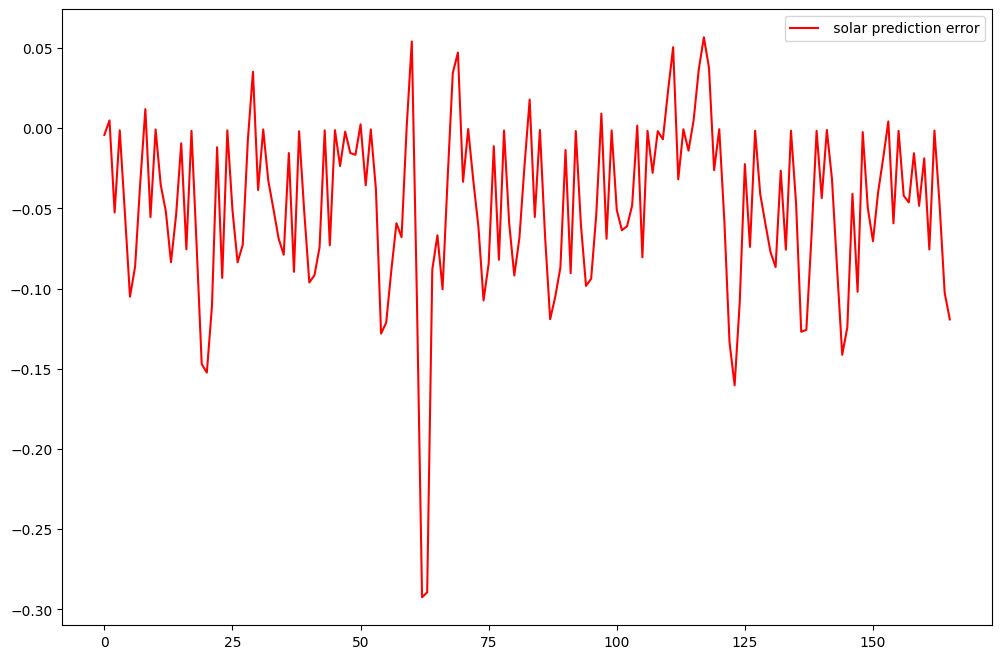

In [12]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),0]-Y_test[:int(len(Y_test)/10),0],color='red',label=' solar prediction error')
#plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),0],color='blue',label='test data')
plt.legend()
plt.show()

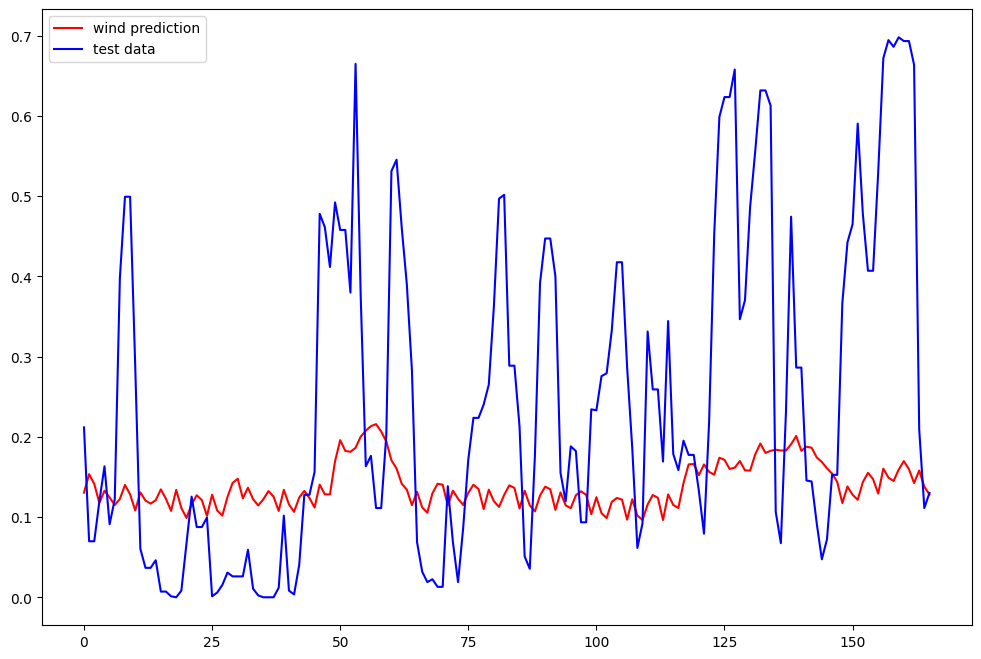

In [13]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),1],color='red',label='wind prediction')
plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),1],color='blue',label='test data')
plt.legend()
plt.show()

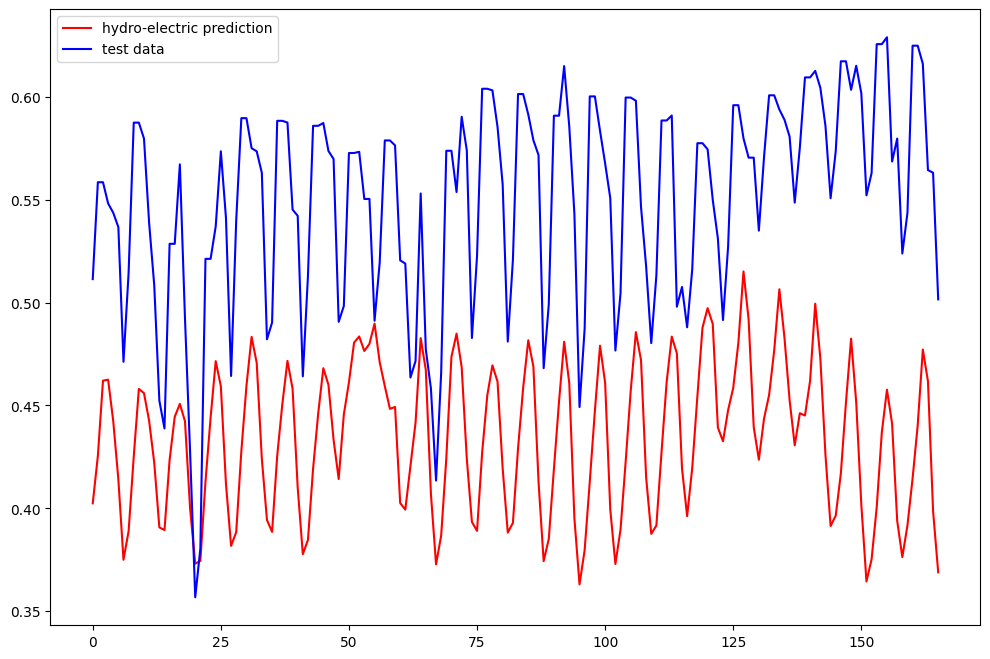

In [14]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),2],color='red',label='hydro-electric prediction')
plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),2],color='blue',label='test data')
plt.legend()
plt.show()

## GRID SEARCH WITH K-FOLD CROSS VALIDATION

In [17]:
import json
import optuna
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit

# here we perform a grid search to look for the best hyperparameters: we choose to use 4 folds. We fix as objective to minimize the average validation error over the folds
# To compute each loss estimation before udating the weights, we perform 100 evaluations of the predicted outputs and consider their average as prediction

def get_activation(name):
    return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()
    }[name]

# load best VAE hyperparamters config previously found
#with open("/home/weights_VAE/vae_best_model_n100.json", "r") as f:
#    vae_best_params = json.load(f)
#print(vae_best_params )
#vae_weights_path = "/home/weights_VAE/vae_best_model_weights_n100.pt"

def objective(trial):
   
    hidden_dim1 = trial.suggest_categorical("hidden_dim1", [128,256]) # previous range 64-256
    hidden_dim2 = trial.suggest_categorical("hidden_dim2", [64,128]) #  previous range 64-256
    latent_dim = trial.suggest_categorical("latent_dim", [12,14,16,18,20]) # previous range 6-20
    hidden_dim3 = trial.suggest_categorical("hidden_dim3",[256] )  # previous range 64-256

    N1 = trial.suggest_categorical("N1", [64,128,256]) # previous range 16-256
    N2 = trial.suggest_categorical("N2", [64,128,256])

    lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6,1e-4, log=True)
    lr = trial.suggest_float("lr",1e-5,1e-4, log=True)
    act_name = trial.suggest_categorical("activation", ["relu"]) # previous searches also with sigmoid and leaky relu 
    activation_fn = get_activation(act_name)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 110
    batch_size = 16
    beta = 1./800
    num_folds = 2
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        #vae_act = get_activation("relu")

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            # hidden_dim1=vae_best_params["H_DIM"],
            # latent_dim=vae_best_params["Z_DIM"],
            # hidden_dim2=vae_best_params["H_DIM"],
            hidden_dim1=hidden_dim1,
            hidden_dim2=hidden_dim2,
            latent_dim=latent_dim,
            hidden_dim3=hidden_dim3,
            vae_activation= activation_fn,
            N1=N1,
            N2=N2,
            No=Y_train_fold.shape[1],
            activation=activation_fn,
            lambda_tik=lambda_tik
        ).to(device)

        # load pretrained VAE weights

        #     key_mapping = {
        # 'img_2hid.weight': 'vae.fc1.weight',
        # 'img_2hid.bias': 'vae.fc1.bias',
        # 'hid_2mu.weight': 'vae.fc_mu.weight',
        # 'hid_2mu.bias': 'vae.fc_mu.bias',
        # 'hid_2sigma.weight': 'vae.fc_logvar.weight',
        # 'hid_2sigma.bias': 'vae.fc_logvar.bias',
        # 'z_2hid.weight': 'vae.fc2.weight',
        # 'z_2hid.bias': 'vae.fc2.bias',
        # 'hid_2img.weight': 'vae.fc3.weight',
        # 'hid_2img.bias': 'vae.fc3.bias'
        # }

        #     # we load pretrained weights and apply mapping to match dictionary keys

        #     raw_pretrained_dict = torch.load(vae_weights_path, map_location=device)
        #     model_dict = model.state_dict()

        #     mapped_dict = {}
        #     for old_k, new_k in key_mapping.items():
        #         if new_k in model_dict and old_k in raw_pretrained_dict:
        #             mapped_dict[new_k] = raw_pretrained_dict[old_k]

        # update the weights of the pre trained vae model
        #     model_dict.update(mapped_dict)
        #     model.load_state_dict(model_dict)

        #    for name, param in model.named_parameters():
        #        if name in mapped_dict:
        #             param.requires_grad = False  # freeze previosuly trained VAE weights!

        #print("Model state dict keys:")
        #for k in model_dict.keys():
            #print(k)
        #print("Pre-trained dict: ", mapped_dict,"\n")

        #print("\n Ensure VAE weights are correctly loaded:")

        #for name in mapped_dict:
        #   current = model.state_dict()[name]
        #   loaded = mapped_dict[name]

        #if torch.allclose(current, loaded, atol=1e-6):
        #print(f" - {name}: OK")
        #else:
        #print(f" - {name}: Divergence in loaded weights!!")

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,       ## wait 8 epochs of no improvement after which shrink LR by half
            patience=10)      

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                # n=1
                # train_out=[]
                # train_recon_x=[]
                # for i in range(n):
                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                #train_out.append(regr_output)
                #train_recon_x.append(recon_x)

                #train_out_tensor = torch.stack(train_out)
                #train_recon_x_tensor = torch.stack(train_recon_x)

                #mean_regr_output = train_out_tensor.mean(dim=0)
                #mean_recon_x = train_recon_x_tensor.mean(dim=0)

                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1-beta)*regr_loss + beta * vae_loss  # this trick normalizes each loss to 1.0, but keeps its gradient direction (only the numerator contributes to the backward pass)
                #loss = (1-beta)*regr_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
               
                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            # validation

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch=0.
            val_regr_loss_epoch=0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                    #val_out=[]
                    #val_recon_x=[]
                    #for i in range(n):
                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    #val_out.append(regr_output)
                    #val_recon_x.append(recon_x)

                    #val_out_tensor = torch.stack(val_out)
                    #val_recon_x_tensor = torch.stack(val_recon_x)

                    #mean_regr_output = val_out_tensor.mean(dim=0)
                    #mean_recon_x = val_recon_x_tensor.mean(dim=0)

                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1-beta)*regr_loss + beta * vae_loss
                    #val_loss= (1-beta)*regr_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            epoch_train_losses[epoch] += (train_loss_epoch)/num_folds
            epoch_val_losses[epoch] += (val_loss_epoch)/num_folds
            epoch_val_vae_losses[epoch] += (val_vae_loss_epoch)/num_folds
            epoch_val_regr_losses[epoch] += (val_regr_loss_epoch)/num_folds

            print(f"Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    model_path = f"weights_VAE_Regression/New_2/model_trial_{trial.number}.pt"
    torch.save(model.state_dict(), model_path)
    trial.set_user_attr("model_path", model_path) # to later have the path of the best model

    return np.mean(epoch_val_regr_losses[-15:])  # loss Optuna will minimize this with the hyper paramters search


In [14]:
#print(vae_best_params)
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#pretrained_dict = torch.load(vae_weights_path, map_location=device)
#print("Loaded keys from pretrained_dict:")
#for k in pretrained_dict.keys():
#    print(k)

Loaded keys from pretrained_dict:
img_2hid.weight
img_2hid.bias
hid_2mu.weight
hid_2mu.bias
hid_2sigma.weight
hid_2sigma.bias
z_2hid.weight
z_2hid.bias
hid_2img.weight
hid_2img.bias


In [10]:
#study = optuna.create_study(directions=["minimize","minimize"],pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=45))
from tqdm import tqdm
n_trials = 90
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-05-31 13:01:56,455] A new study created in memory with name: no-name-cf17780d-e1e7-4ad9-beb8-a780cdd7164d
Optuna Trials:   0%|                                                                          | 0/90 [00:00<?, ?trial/s]

Epoch [1/110] - Total val loss: 133.8330, VAE: 680.4694, Regr: 133.1488
Epoch [2/110] - Total val loss: 120.3017, VAE: 675.2885, Regr: 119.6071
Epoch [3/110] - Total val loss: 107.8973, VAE: 675.4473, Regr: 107.1869
Epoch [4/110] - Total val loss: 96.6780, VAE: 679.5582, Regr: 95.9485
Epoch [5/110] - Total val loss: 86.7492, VAE: 683.5464, Regr: 86.0022
Epoch [6/110] - Total val loss: 77.8069, VAE: 689.5915, Regr: 77.0413
Epoch [7/110] - Total val loss: 69.7886, VAE: 696.6071, Regr: 69.0041
Epoch [8/110] - Total val loss: 62.7359, VAE: 704.2128, Regr: 61.9330
Epoch [9/110] - Total val loss: 56.4916, VAE: 709.3362, Regr: 55.6745
Epoch [10/110] - Total val loss: 51.0390, VAE: 714.8977, Regr: 50.2081
Epoch [11/110] - Total val loss: 46.2391, VAE: 718.8984, Regr: 45.3972
Epoch [12/110] - Total val loss: 41.9613, VAE: 721.3610, Regr: 41.1110
Epoch [13/110] - Total val loss: 38.2372, VAE: 725.0845, Regr: 37.3776
Epoch [14/110] - Total val loss: 34.9181, VAE: 724.0273, Regr: 34.0557
Epoch [15

[I 2025-05-31 13:09:49,917] Trial 0 finished with value: 5.447134469681793 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 256, 'N1': 256, 'N2': 256, 'lambda_tik': 2.982030723197395e-05, 'lr': 1.6224813762064538e-05, 'activation': 'relu'}. Best is trial 0 with value: 5.447134469681793.
Optuna Trials:   1%|▋                                                             | 1/90 [07:53<11:42:17, 473.45s/trial]

Epoch [110/110] - Total val loss: 6.2677, VAE: 1009.7631, Regr: 5.0117
Epoch [1/110] - Total val loss: 45.3170, VAE: 686.1439, Regr: 44.5149
Epoch [2/110] - Total val loss: 34.7128, VAE: 718.1281, Regr: 33.8575
Epoch [3/110] - Total val loss: 26.4289, VAE: 738.5522, Regr: 25.5377
Epoch [4/110] - Total val loss: 20.1083, VAE: 749.8609, Regr: 19.1950
Epoch [5/110] - Total val loss: 15.5952, VAE: 748.4554, Regr: 14.6780
Epoch [6/110] - Total val loss: 12.2835, VAE: 756.3279, Regr: 11.3523
Epoch [7/110] - Total val loss: 9.8887, VAE: 758.9453, Regr: 8.9512
Epoch [8/110] - Total val loss: 8.0661, VAE: 759.1929, Regr: 7.1260
Epoch [9/110] - Total val loss: 6.8295, VAE: 756.9528, Regr: 5.8907
Epoch [10/110] - Total val loss: 5.9007, VAE: 752.7005, Regr: 4.9660
Epoch [11/110] - Total val loss: 5.2286, VAE: 743.6341, Regr: 4.3045
Epoch [12/110] - Total val loss: 4.7282, VAE: 732.6375, Regr: 3.8172
Epoch [13/110] - Total val loss: 4.3781, VAE: 721.1239, Regr: 3.4811
Epoch [14/110] - Total val lo

[I 2025-05-31 13:16:53,773] Trial 1 finished with value: 0.927561286877957 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 5.04506263165086e-05, 'lr': 7.718651039106131e-05, 'activation': 'relu'}. Best is trial 1 with value: 0.927561286877957.
Optuna Trials:   2%|█▍                                                            | 2/90 [14:57<10:51:36, 444.28s/trial]

...

Epoch [110/110] - Total val loss: 1.8597, VAE: 517.5774, Regr: 1.2143
Epoch [1/110] - Total val loss: 10.0525, VAE: 696.8169, Regr: 9.1930
Epoch [2/110] - Total val loss: 9.0036, VAE: 755.3063, Regr: 8.0695
Epoch [3/110] - Total val loss: 7.7156, VAE: 758.2833, Regr: 6.7762
Epoch [4/110] - Total val loss: 6.7334, VAE: 765.1619, Regr: 5.7842
Epoch [5/110] - Total val loss: 5.9018, VAE: 768.0751, Regr: 4.9479
Epoch [6/110] - Total val loss: 5.2583, VAE: 765.0128, Regr: 4.3074
Epoch [7/110] - Total val loss: 4.7030, VAE: 760.3306, Regr: 3.7573
Epoch [8/110] - Total val loss: 4.3062, VAE: 764.2971, Regr: 3.3550
Epoch [9/110] - Total val loss: 3.9697, VAE: 761.4660, Regr: 3.0217
Epoch [10/110] - Total val loss: 3.6615, VAE: 747.1026, Regr: 2.7311
Epoch [11/110] - Total val loss: 3.3938, VAE: 733.5790, Regr: 2.4800
Epoch [12/110] - Total val loss: 3.2143, VAE: 713.4094, Regr: 2.3254
Epoch [13/110] - Total val loss: 3.0175, VAE: 689.8467, Regr: 2.1579
Epoch [14/110] - Total val loss: 2.8690, 

[I 2025-06-01 10:22:08,109] Trial 88 finished with value: 2.2059818094422066 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 12, 'hidden_dim3': 256, 'N1': 256, 'N2': 64, 'lambda_tik': 1.0568069872994483e-05, 'lr': 7.470071661604657e-05, 'activation': 'relu'}. Best is trial 1 with value: 0.927561286877957.
Optuna Trials:  99%|███████████████████████████████████████████████████████████▎| 89/90 [21:20:11<55:43, 3343.30s/trial]

Epoch [110/110] - Total val loss: 2.6262, VAE: 524.8904, Regr: 1.9726
Epoch [1/110] - Total val loss: 27.4004, VAE: 685.5373, Regr: 26.5767
Epoch [2/110] - Total val loss: 19.6287, VAE: 704.3696, Regr: 18.7717
Epoch [3/110] - Total val loss: 14.8498, VAE: 721.1146, Regr: 13.9658
Epoch [4/110] - Total val loss: 11.7353, VAE: 729.4588, Regr: 10.8370
Epoch [5/110] - Total val loss: 9.6223, VAE: 734.2274, Regr: 8.7154
Epoch [6/110] - Total val loss: 8.0651, VAE: 737.3029, Regr: 7.1524
Epoch [7/110] - Total val loss: 6.9084, VAE: 737.9175, Regr: 5.9935
Epoch [8/110] - Total val loss: 6.1398, VAE: 741.8353, Regr: 5.2190
Epoch [9/110] - Total val loss: 5.5244, VAE: 742.7250, Regr: 4.6018
Epoch [10/110] - Total val loss: 5.0206, VAE: 753.7214, Regr: 4.0836
Epoch [11/110] - Total val loss: 4.6874, VAE: 760.7493, Regr: 3.7412
Epoch [12/110] - Total val loss: 4.3910, VAE: 759.2345, Regr: 3.4463
Epoch [13/110] - Total val loss: 4.1496, VAE: 763.0132, Regr: 3.1999
Epoch [14/110] - Total val loss: 3

[I 2025-06-01 10:29:46,260] Trial 89 finished with value: 2.0121822160889775 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 18, 'hidden_dim3': 256, 'N1': 256, 'N2': 256, 'lambda_tik': 7.116144154834405e-06, 'lr': 6.682763658359221e-05, 'activation': 'relu'}. Best is trial 1 with value: 0.927561286877957.
Optuna Trials: 100%|█████████████████████████████████████████████████████████████| 90/90 [21:27:49<00:00, 858.55s/trial]

Epoch [110/110] - Total val loss: 2.6953, VAE: 535.4253, Regr: 2.0285


In [27]:
best_trial_1= study.best_trial
best_params_1 = best_trial.params
print(best_params_1)

{'hidden_dim1': 128, 'hidden_dim2': 128, 'latent_dim': 14, 'hidden_dim3': 256, 'N1': 32, 'N2': 128, 'lambda_tik': 0.0001425151107702199, 'lr': 0.00017206350238630318, 'activation': 'relu'}


In [10]:
best_trial_2= study.best_trial
best_params_2 = best_trial.params
print(best_params_2)

{'hidden_dim1': 128, 'hidden_dim2': 64, 'latent_dim': 20, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 3.096176320371018e-05, 'lr': 0.0004154465741986691, 'activation': 'relu'}


In [11]:
best_trial = study.best_trial
best_params = best_trial.params
print(best_params)

{'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 5.04506263165086e-05, 'lr': 7.718651039106131e-05, 'activation': 'relu'}


# GRAPHS

We run another grid search with restricted intervals for the different hyperparamters.

In [12]:
import json

# choose the model with best trade-off between regression and valid loss
best_trial= study.best_trial
#pareto_trials = study.best_trials
##
#losses = np.array([t.values for t in pareto_trials])  # shape: (n_trials, 2)
##
#vae_losses = losses[:, 0]
#regr_losses = losses[:, 1]
##
### normalize losses to [0, 1] to compare
##
#eps = 1e-8
#vae_range = vae_losses.max() - vae_losses.min()
#regr_range = regr_losses.max() - regr_losses.min()
#
#vae_norm = (vae_losses - vae_losses.min()) / (vae_range + eps)
#regr_norm = (regr_losses - regr_losses.min()) / (regr_range + eps)
#
### define a distance metric from the origin (ideal point with 0 loss) and choose trial with lower distance
#distances = np.sqrt(vae_norm**2 + regr_norm**2)
#best_idx = np.argmin(distances)
##best_idx=0
#best_trial = pareto_trials[best_idx]



# get its best hyperparameters
best_activation = get_activation(best_params["activation"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


best_model = VAE_Regression(
            input_dim= X_train.shape[1],
           # hidden_dim1=vae_best_params["H_DIM"],
           # latent_dim=vae_best_params["Z_DIM"],
           # hidden_dim2=vae_best_params["H_DIM"],
            hidden_dim1=best_params['hidden_dim1'],
            hidden_dim2=best_params['hidden_dim2'],
            latent_dim=best_params['latent_dim'],
            hidden_dim3=best_params['hidden_dim3'],
            vae_activation= best_activation,
            N1=best_params['N1'],
            N2=best_params['N2'],
            No=Y_train.shape[1],
            activation= best_activation,
            lambda_tik=best_params['lambda_tik']
        ).to(device)

#best_model = VAE_Regression(
#    input_dim=X_train_tensor.shape[1],
#    hidden_dim1=vae_best_params["H_DIM"],
#    latent_dim=vae_best_params["Z_DIM"],
#    hidden_dim2=vae_best_params["H_DIM"],
#    vae_activation=best_activation,
#    N1=best_params["N1"],
#    N2=best_params["N2"],
#    No=Y_train_tensor.shape[1],
#    activation=best_activation,
#    lambda_tik=best_params["lambda_tik"]
#).to(device)

# load the weights of the best trial
best_model.load_state_dict(torch.load(best_trial.user_attrs["model_path"]))

trial=0
trial += 1
# saves current hyperparamters and weights (which you just loaded) into a new file

with open("best_Regr_models/best_model_3_June_hyperparams.json", "w") as f:
    json.dump(best_params, f)

torch.save(best_model.state_dict(), f"best_Regr_models/best_model_3_June_{trial}.pt")


/tmp/ipykernel_300/2359636402.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_trial.user_attrs["model_path"]))


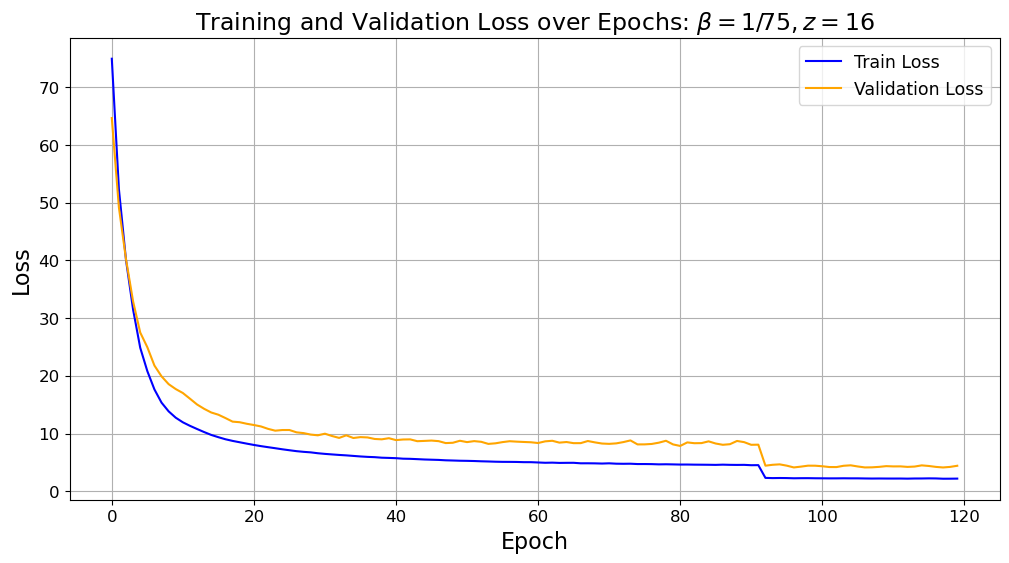

In [136]:
# plot training and validation losses over epochs
#best_model.load_state_dict(torch.load("lcpb_files/best_model_overall.pt"))

train_loss_curve = np.array(best_trial.user_attrs["mean_train_loss_curve"])
val_loss_curve = np.array(best_trial.user_attrs["mean_val_loss_curve"])
val_vae_loss_curve = np.array(best_trial.user_attrs["mean_val_vae_loss_curve"])
val_regr_loss_curve = np.array(best_trial.user_attrs["mean_val_regr_loss_curve"])

epochs = np.arange(len(train_loss_curve))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve, label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve, label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(r"Training and Validation Loss over Epochs: $\beta=1/75,z=16$")
plt.legend()
plt.grid(True)
plt.savefig("plots/best_model_3_June_loss_beta_1_75_z_16_new.png", dpi=300, bbox_inches='tight')
plt.show()


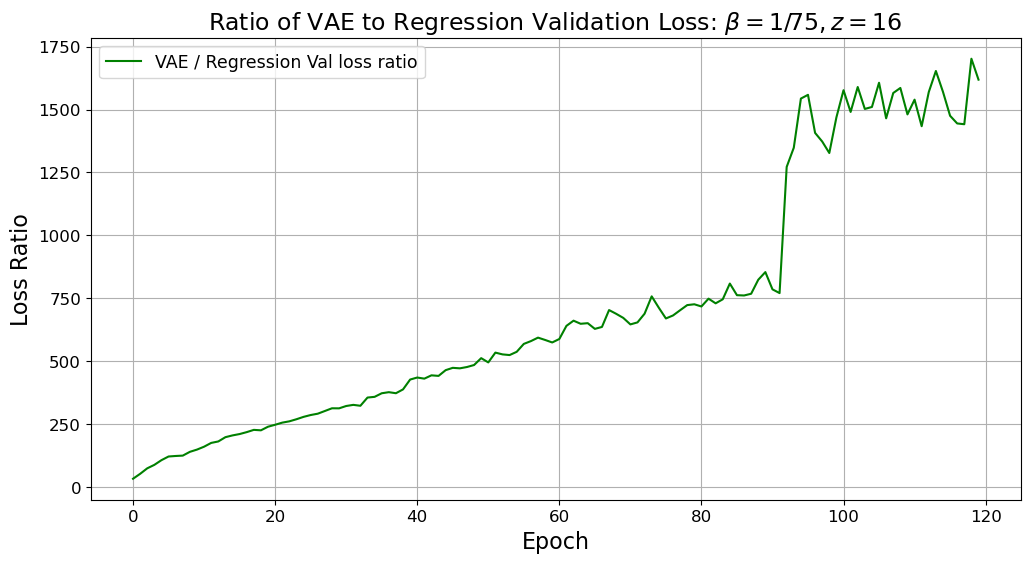

<Figure size 640x480 with 0 Axes>

In [118]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio, label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(r"Ratio of VAE to Regression Validation Loss: $\beta=1/75,z=16$")
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("plots/best_model_3_June_ratio_beta_1_75_z_16_new.png", dpi=300, bbox_inches='tight')

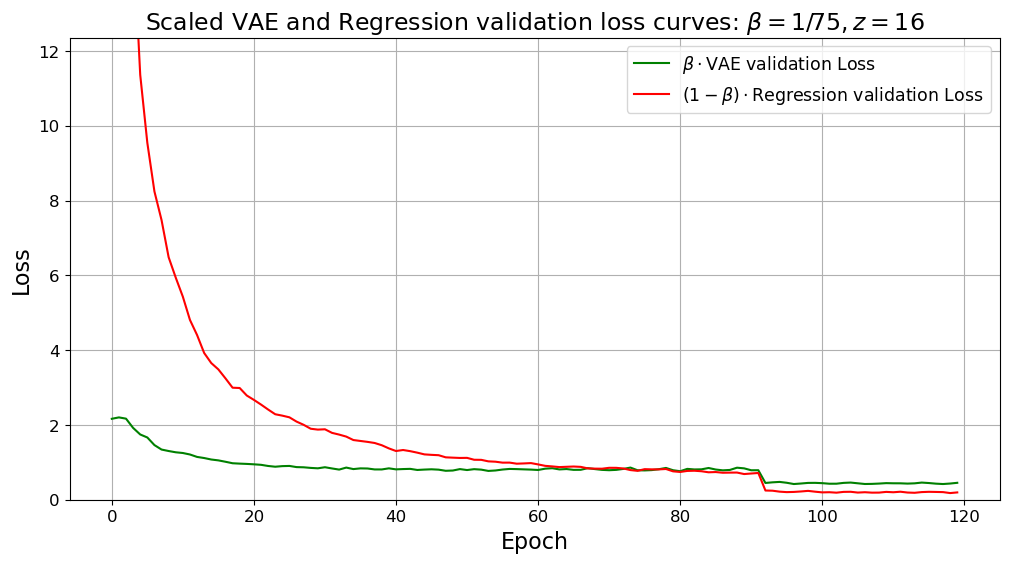

In [138]:
fig,ax= plt.subplots(figsize=(12,6))
beta = 1./700
ax.plot(epochs, beta*val_vae_loss_curve, label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(r"Scaled VAE and Regression validation loss curves: $\beta=1/75,z=16$")

ax.plot(epochs, (1-beta)*val_regr_loss_curve, label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(0,3*np.min(val_loss_curve))
ax.grid(True)
ax.legend()
plt.savefig("plots/best_model_3_June_vae_regr_losses_beta_1_75_z_16_new.png", dpi=300, bbox_inches='tight')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/samu/LCP-b/plots/Solar_predictions/best_model_beta_1/1000_z_20.png'

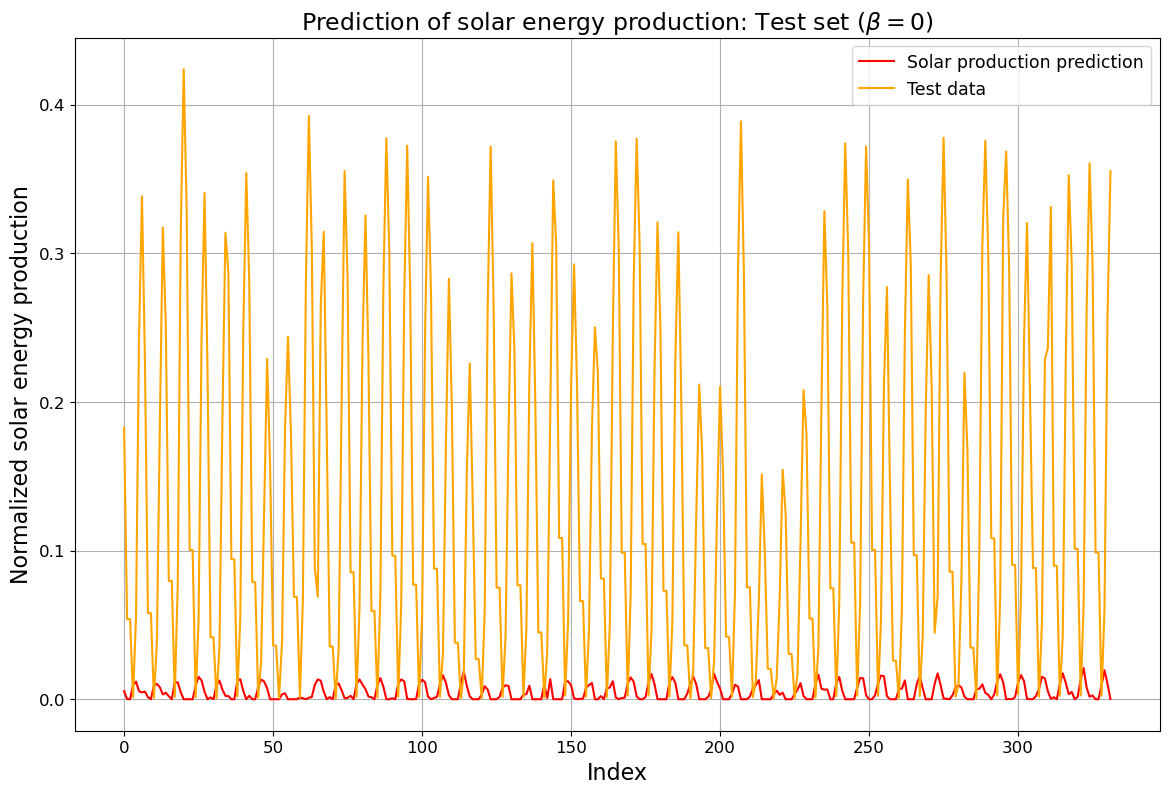

In [96]:
# NO!



#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#recon_x_vec = []
#test_predictions=[]
#
#with torch.no_grad(): # disable gradient calculation for inference
#    for i in range(4000):
#      regr_output, reconstructed_x, mu, logvar, z = model(X_test_tensor.to(device))
#      test_predictions.append(regr_output)  # shape: [100, test_size, 3]
#      recon_x_vec.append(reconstructed_x)
#
## convert to tensor
#test_predictions_tensor = torch.stack(test_predictions)
#recon_x_tensor= torch.stack(recon_x_vec)
#
## compute mean across the 100 runs: shape becomes [test_size, 3]
#mean_test_predictions = test_predictions_tensor.mean(dim=0)
## mean over passes
#mean_test_predictions = test_predictions_tensor.mean(dim=0).cpu().numpy()
#mean_recon_x_test = recon_x_tensor.mean(dim=0).cpu().numpy()
#
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),0],color='red',label='Solar production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),0],color='orange',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized solar energy production")
plt.title(r"Prediction of solar energy production: Test set ($\beta=0$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/best_model_beta_1/1000_z_20.png", dpi=300, bbox_inches='tight')
plt.show()


[[0.14001584 0.09736891]
 [0.0331269  0.1396284 ]
 [0.01819815 0.0982272 ]
 ...
 [0.01123474 0.12861897]
 [0.         0.1079866 ]
 [0.         0.0827296 ]]


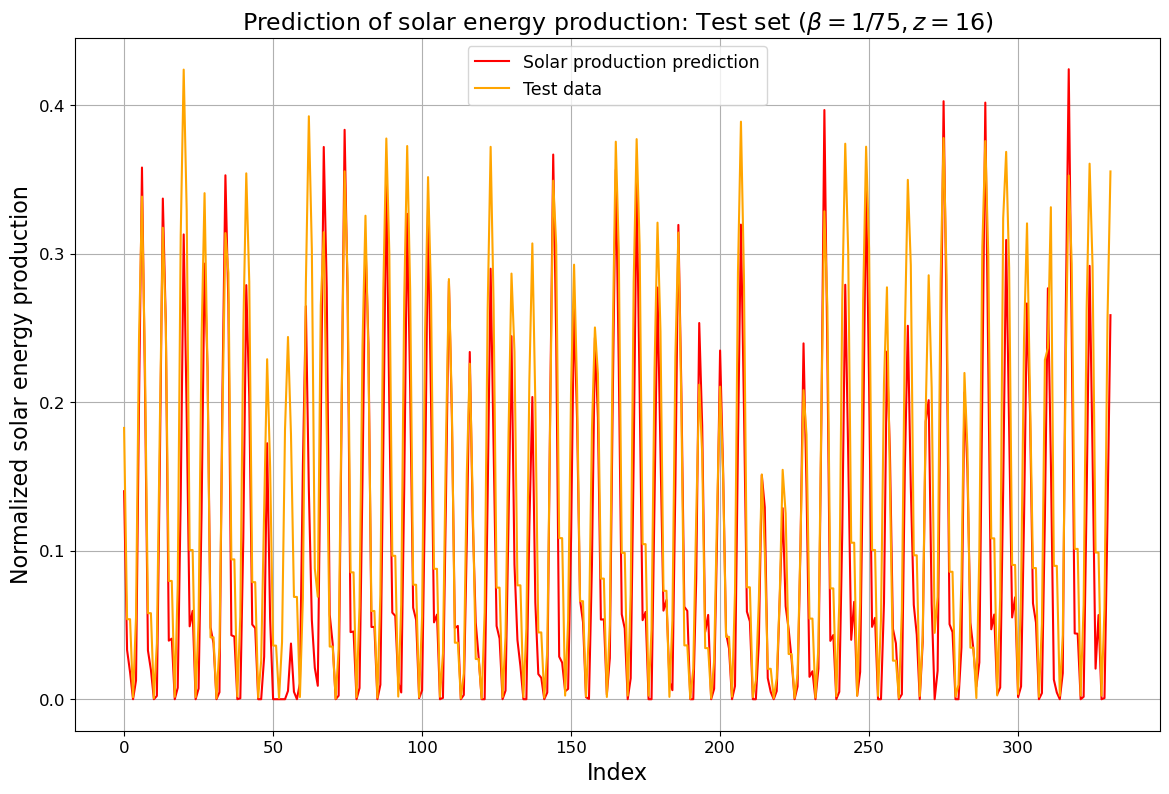

In [129]:
#best_params = best_trial.params
#activation_fn = get_activation(best_params["activation"])

#best_model = VAE_Regression(
#    input_dim= X_test_tensor.shape[1],
#    hidden_dim1=best_params["hidden_dim1"],
#    latent_dim=best_params["latent_dim"],
#    hidden_dim2=best_params["hidden_dim2"],
#    vae_activation=activation_fn,
#    N1=best_params["N1"],
#    N2=best_params["N2"],
#    No=Y_test_tensor.shape[1],
#    activation=activation_fn,
#    lambda_tik=best_params["lambda_tik"]
#    ).to(device)

# best_model.load_state_dict(torch.load(best_trial.user_attrs["model_path"]))

best_model.eval()

num_passes= 200

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()

#z = z.cpu().numpy()

print(mean_test_predictions)

#train_predictions = regr_output_train.cpu().numpy()
#z_train = z_train.cpu().numpy()
#recon_x_train = reconstructed_x_train.cpu().numpy()



# regression test prediction vs test data

plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),0],color='red',label='Solar production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),0],color='orange',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized solar energy production")
plt.title(r"Prediction of solar energy production: Test set ($\beta=1/75,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/best_model_3_June_beta_1_75_z_16_new.png", dpi=300, bbox_inches='tight')
plt.show()

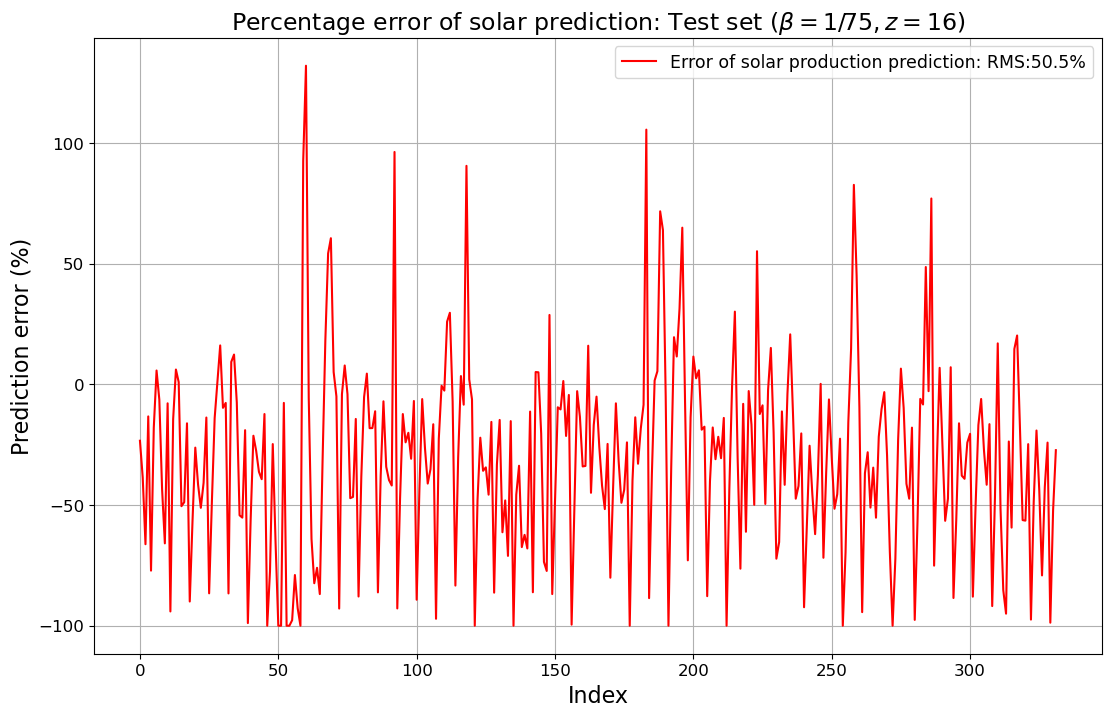

In [133]:
plt.figure(figsize=(13, 8))
error_solar= (mean_test_predictions[:int(len(mean_test_predictions)/5),0]- Y_test[:int(len(Y_test)/5),0]) / np.maximum(Y_test[:int(len(Y_test)/5),0], 1e-2)
#plt.plot(np.arange(int(len(mean_test_predictions)/5)),(mean_test_predictions[:int(len(mean_test_predictions)/5),0]-Y_test[:int(len(Y_test)/5),0])*100/(Y_test[:int(len(Y_test)/5),0]+10**(-4)),color='orange',label='Error of solar production prediction')
plt.plot(np.arange(int(len(mean_test_predictions)/5)), (error_solar*100), color='red', label=f'Error of solar production prediction: RMS:{round(np.sqrt(np.mean((error_solar*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of solar prediction: Test set ($\beta=1/75,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/error_best_model_3_June_beta_1_75_z_16_new.png", dpi=300, bbox_inches='tight')
plt.show()




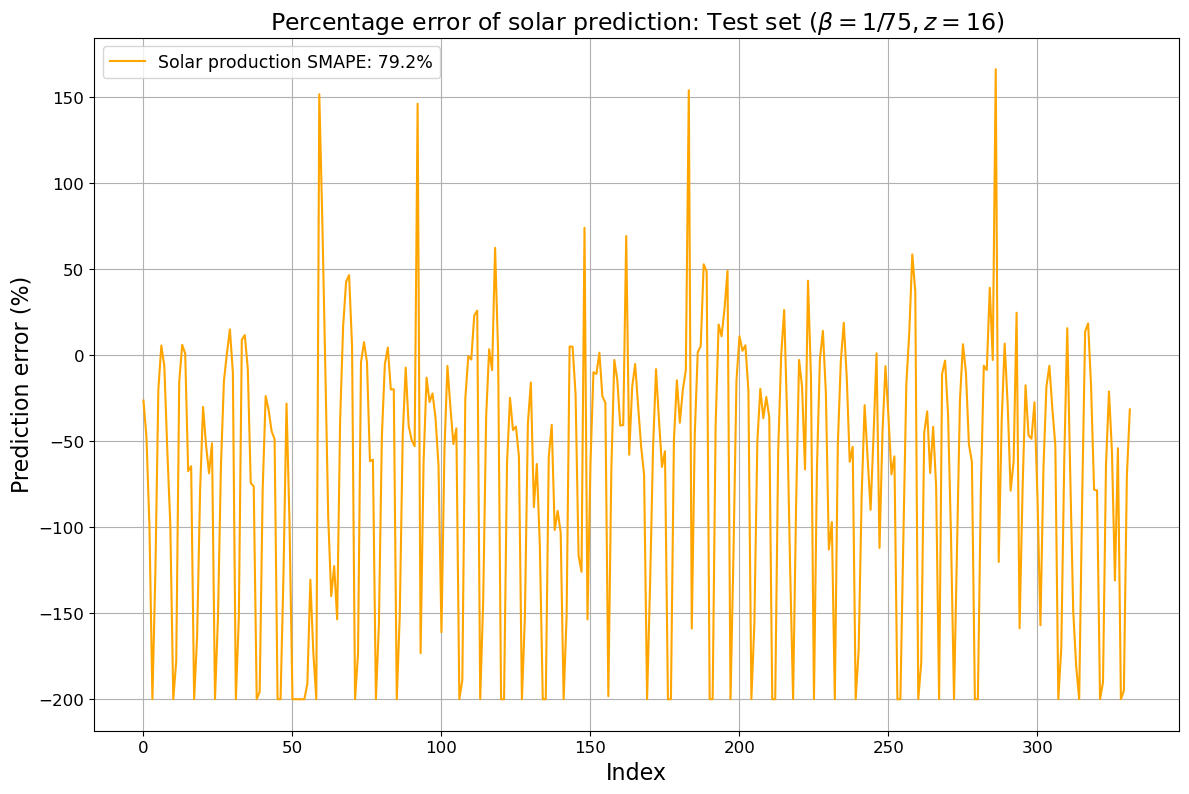

In [134]:
y_true = Y_test[:int(len(Y_test)/5), 0]
y_pred = mean_test_predictions[:int(len(mean_test_predictions)/5), 0]

# compute SMAPE
denom = (np.abs(y_true) + np.abs(y_pred)) / 2
smape = 100 * np.mean(np.where(denom != 0, np.abs(y_pred - y_true) / denom, 0))


percent_error = np.where(denom != 0, (y_pred - y_true) / denom * 100, 0)
plt.figure(figsize=(14, 9))
plt.plot(np.arange(len(percent_error)), percent_error, color='orange',
         label=f'Solar production SMAPE: {round(smape, 1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of solar prediction: Test set ($\beta=1/75,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/smape_error_best_model_3_June_beta_1_75_z_16_new.png", dpi=300, bbox_inches='tight')
plt.show()


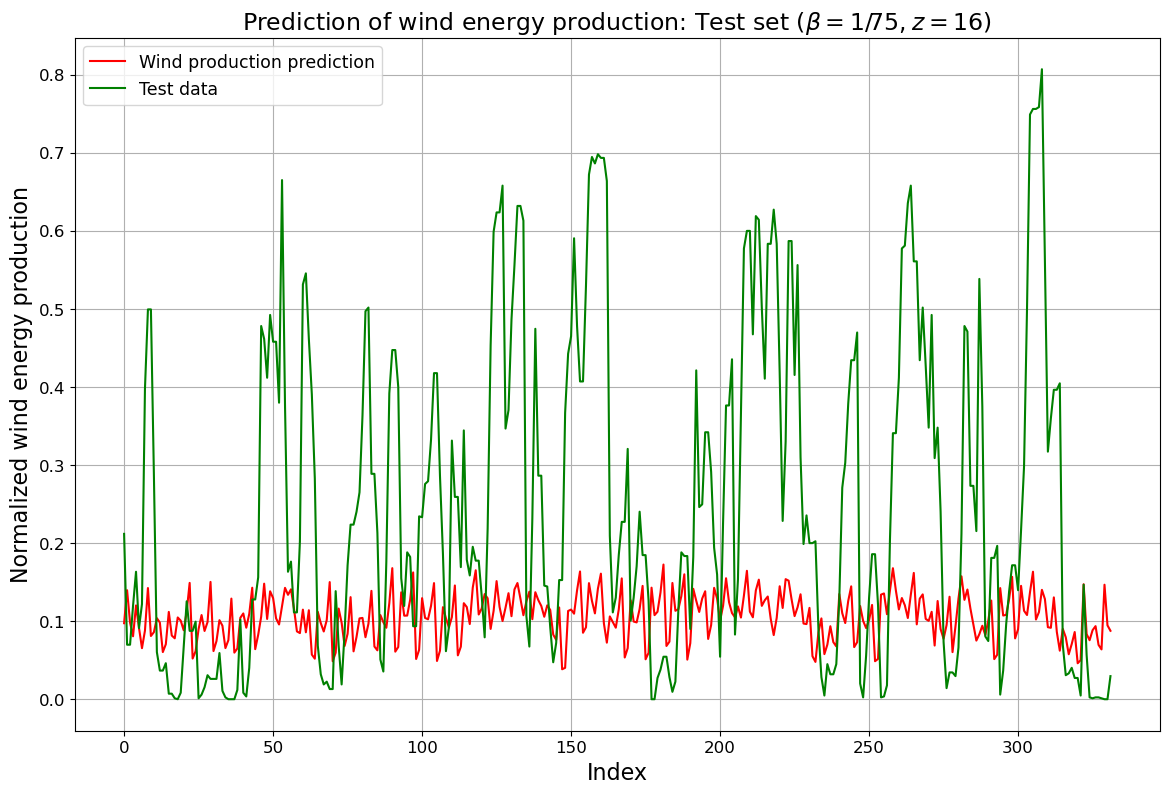

In [132]:
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),1],color='red',label='Wind production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),1],color='green',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized wind energy production")
plt.title(r"Prediction of wind energy production: Test set ($\beta=1/75,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/wind_pred_3_June_beta_1_75_z_16_new.png", dpi=300, bbox_inches='tight')
plt.show()




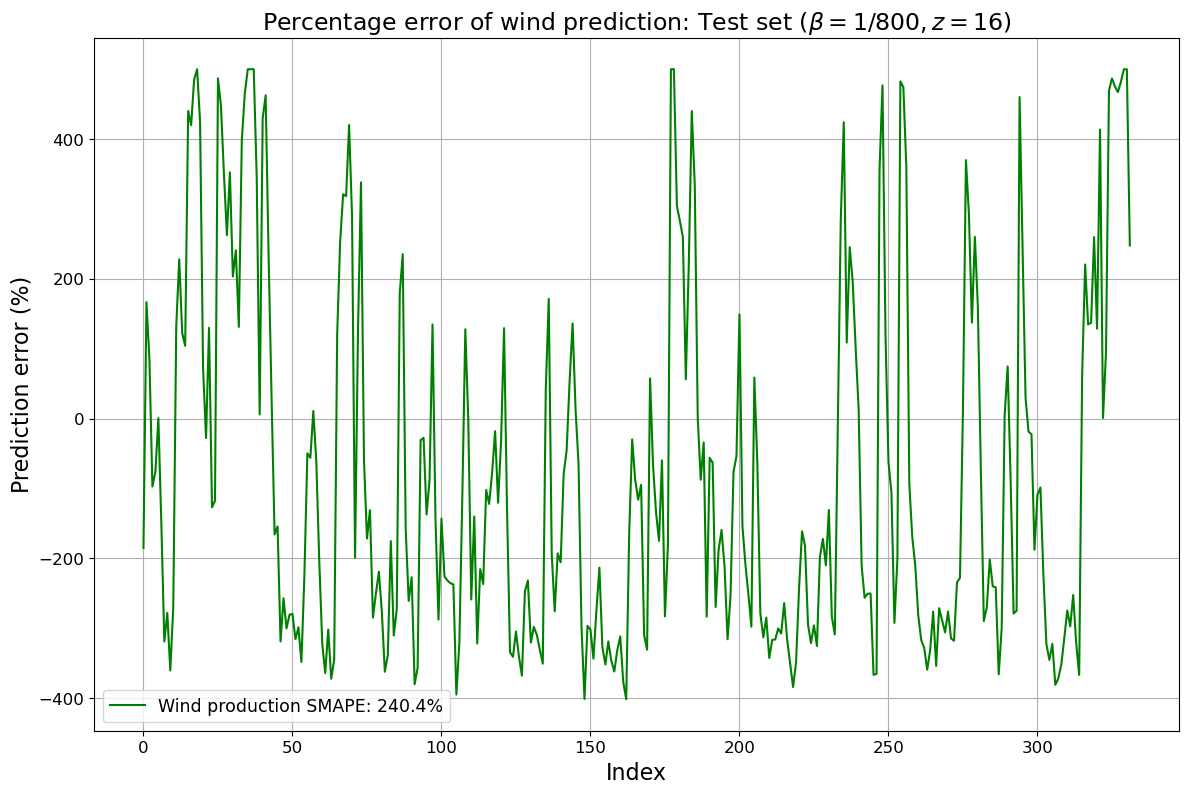

In [124]:
y_true = Y_test[:int(len(Y_test)/5), 1]
y_pred = mean_test_predictions[:int(len(mean_test_predictions)/5), 1]

# compute SMAPE
denom = (np.abs(y_true) + np.abs(y_pred)) / 5
smape = 100 * np.mean(np.where(denom != 0, np.abs(y_pred - y_true) / denom, 0))


percent_error = np.where(denom != 0, (y_pred - y_true) / denom * 100, 0)
plt.figure(figsize=(14, 9))
plt.plot(np.arange(len(percent_error)), percent_error, color='green',
         label=f'Wind production SMAPE: {round(smape, 1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of wind prediction: Test set ($\beta=1/800,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/smape_error_best_model_1_June_beta_1_800_z_16_new.png", dpi=300, bbox_inches='tight')
plt.show()


In [85]:
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),2],color='red',label='Hydro-electric production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),2],color='blue',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized hydro-electric energy production")
plt.title(r"Prediction of hydro-electric energy production: Test set ($\beta=0$)")
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("/home/plots/hydro_pred_beta_0.png", dpi=300, bbox_inches='tight')

IndexError: index 2 is out of bounds for axis 1 with size 2

<Figure size 1400x900 with 0 Axes>

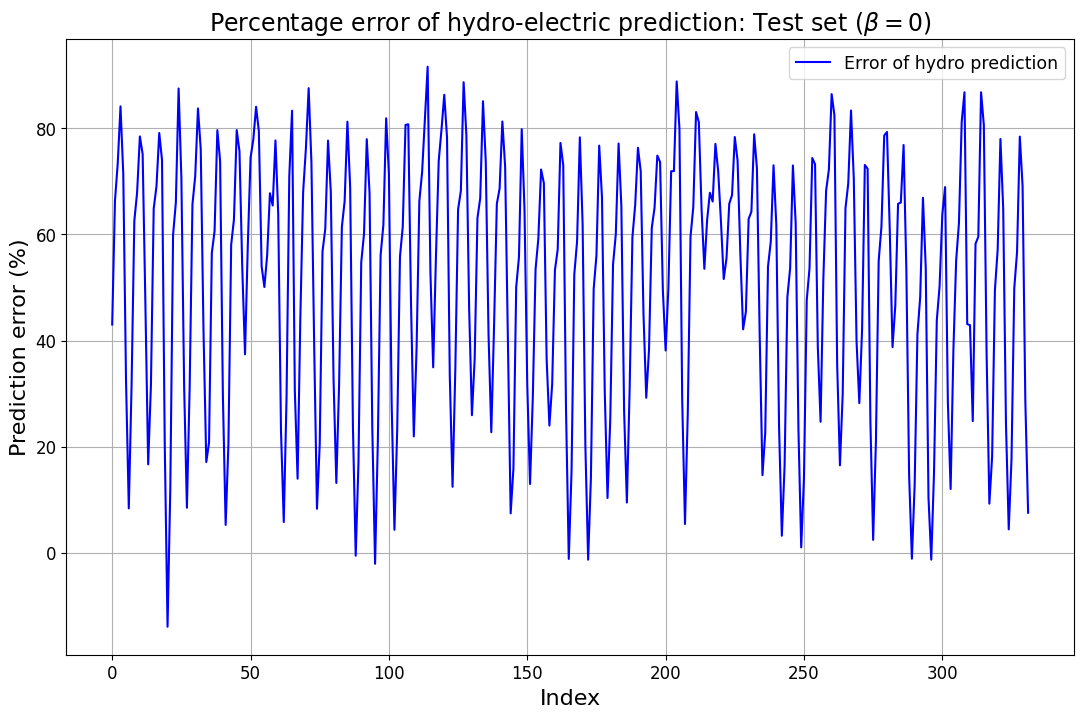

<Figure size 640x480 with 0 Axes>

In [71]:
plt.figure(figsize=(13, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),(mean_test_predictions[:int(len(mean_test_predictions)/5),2]-Y_test[:int(len(Y_test)/5),0])*100/(Y_test[:int(len(Y_test)/5),2]+10**(-4)),color='blue',label='Error of hydro prediction')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of hydro-electric prediction: Test set ($\beta=0$)")
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("/home/plots/hydro_pred_error_beta_0.png", dpi=300, bbox_inches='tight')

## **Input reconstruction: visualization**

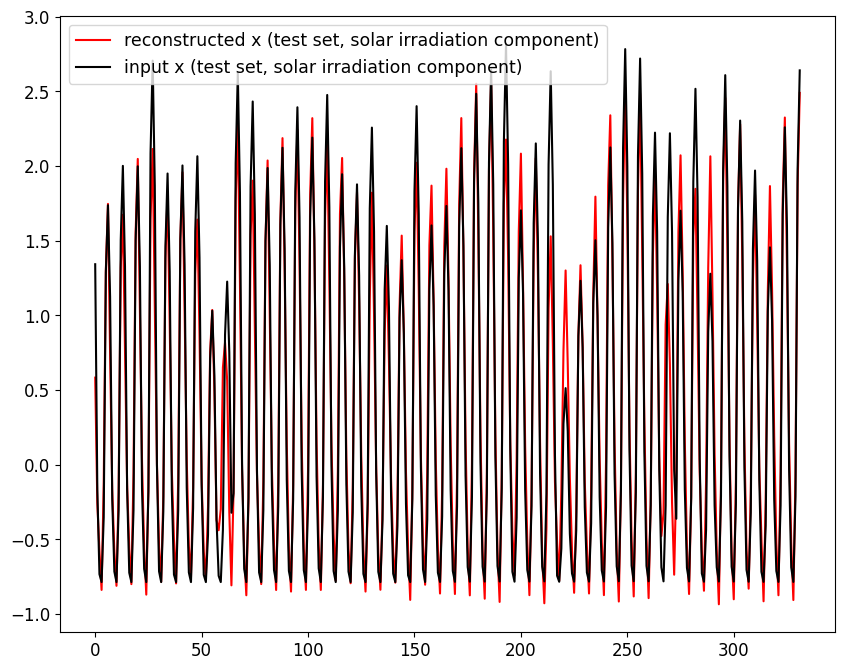

In [38]:

plt.figure(figsize=(10, 8))
plot_length = int(len(mean_recon_x_test)/5)
plt.plot(np.arange(plot_length),mean_recon_x_test[:plot_length,2],color='red',label='reconstructed x (test set, solar irradiation component)')
plt.plot(np.arange(plot_length),X_test[:plot_length,2],color='black',label='input x (test set, solar irradiation component)')

plt.legend()
plt.show()

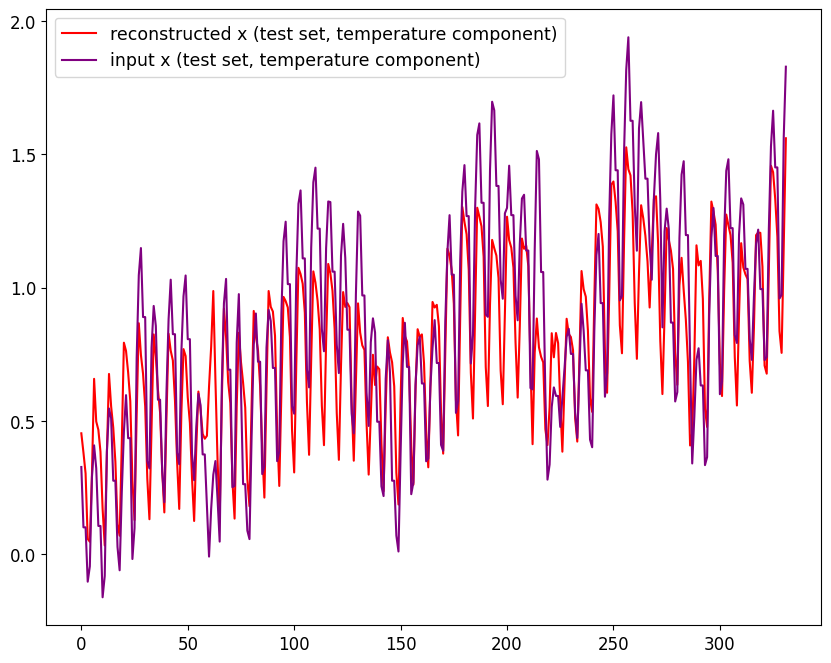

In [39]:
plt.figure(figsize=(10, 8))
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),mean_recon_x_test[:int(len(mean_recon_x_test)/5),1],color='red',label='reconstructed x (test set, temperature component)')
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),X_test[:int(len(mean_recon_x_test)/5),1],color='purple',label='input x (test set, temperature component)')

plt.legend()
plt.show()

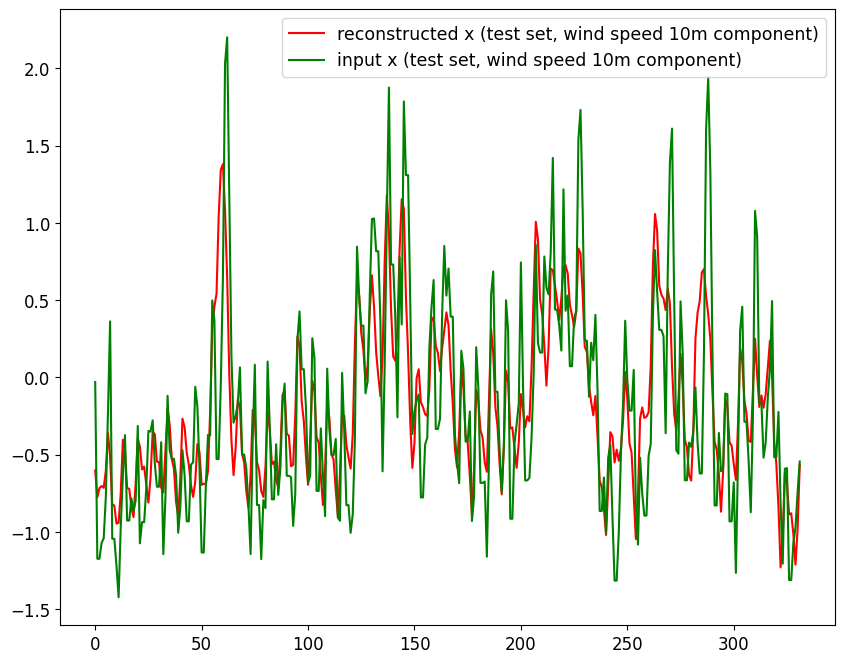

In [40]:
plt.figure(figsize=(10, 8))
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),mean_recon_x_test[:int(len(mean_recon_x_test)/5),4],color='red',label='reconstructed x (test set, wind speed 10m component)')
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),X_test[:int(len(mean_recon_x_test)/5),4],color='green',label='input x (test set, wind speed 10m component)')

plt.legend()
plt.show()

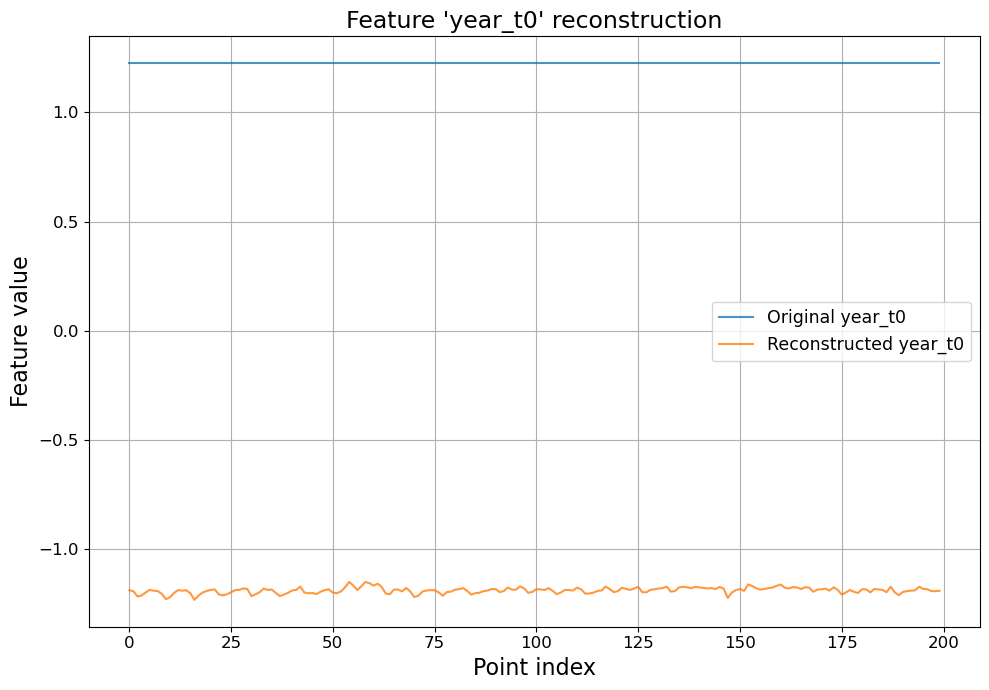

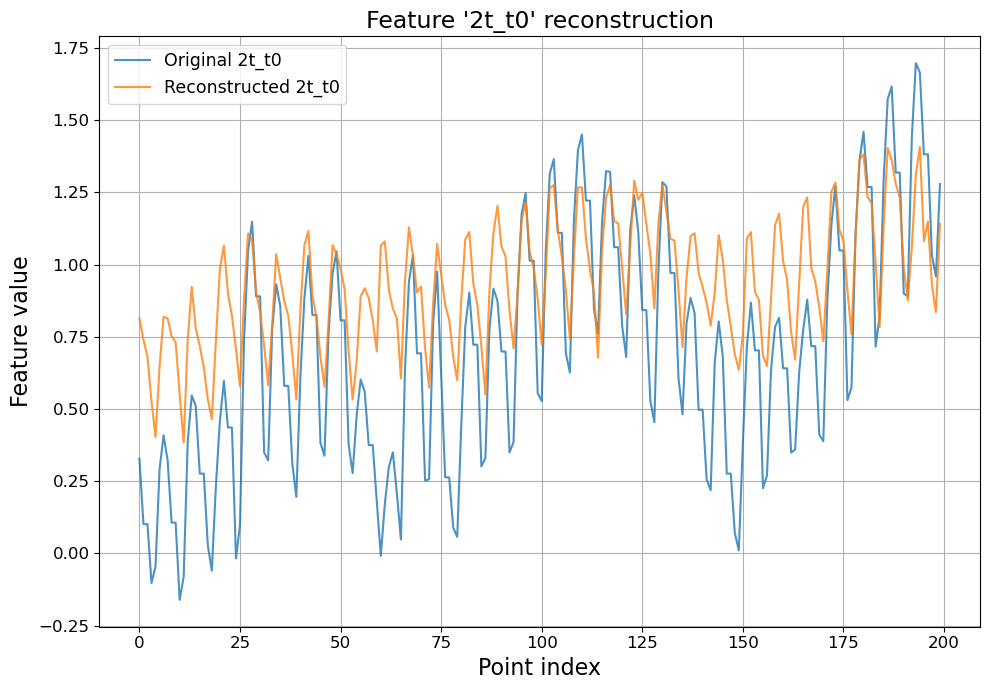

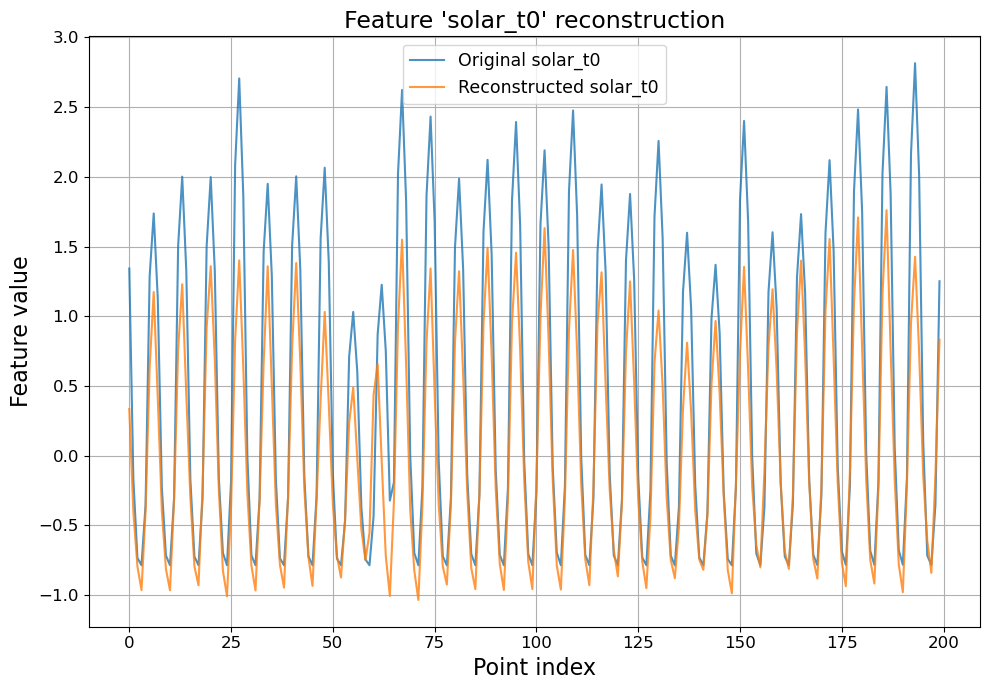

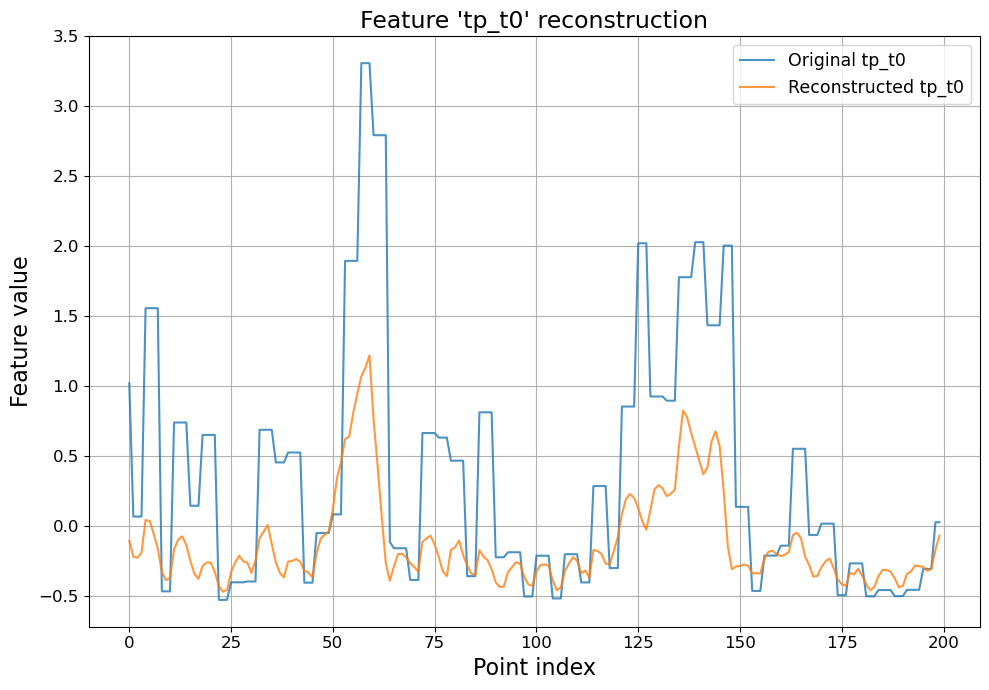

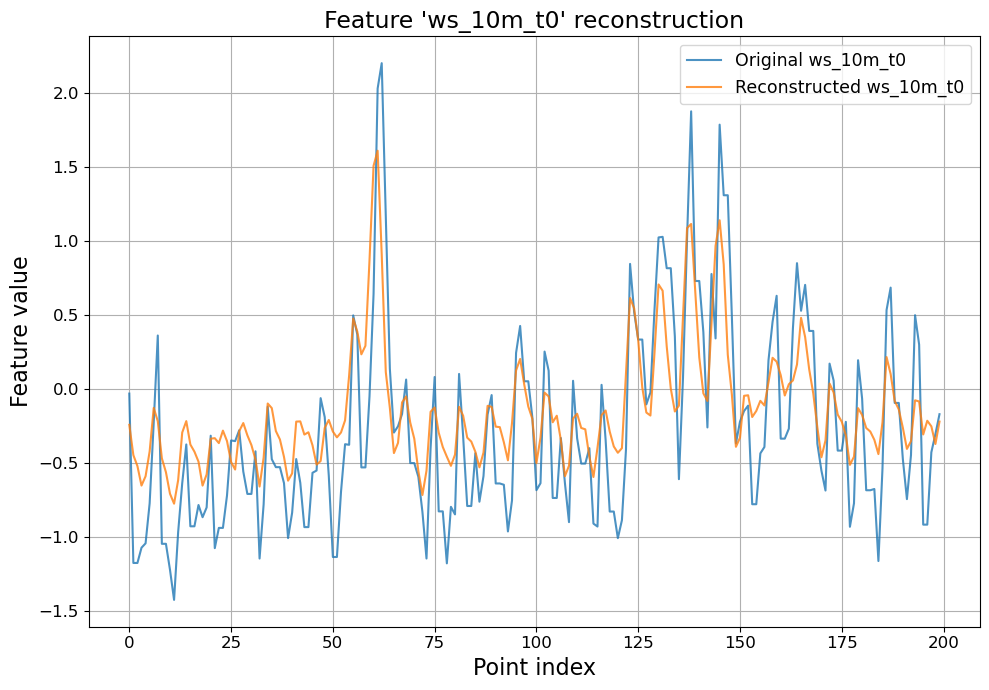

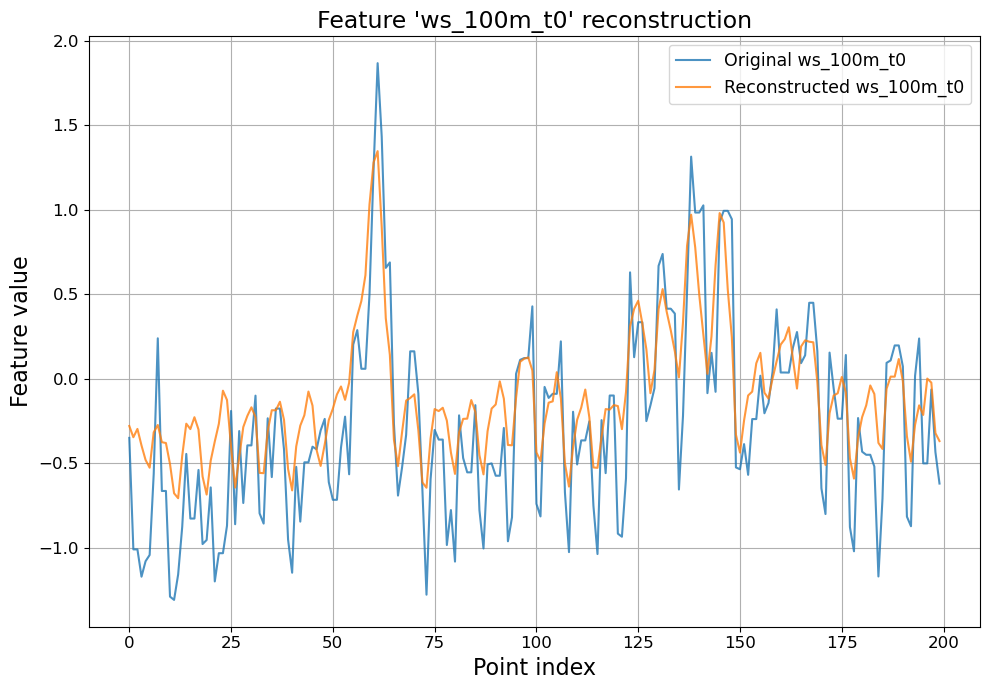

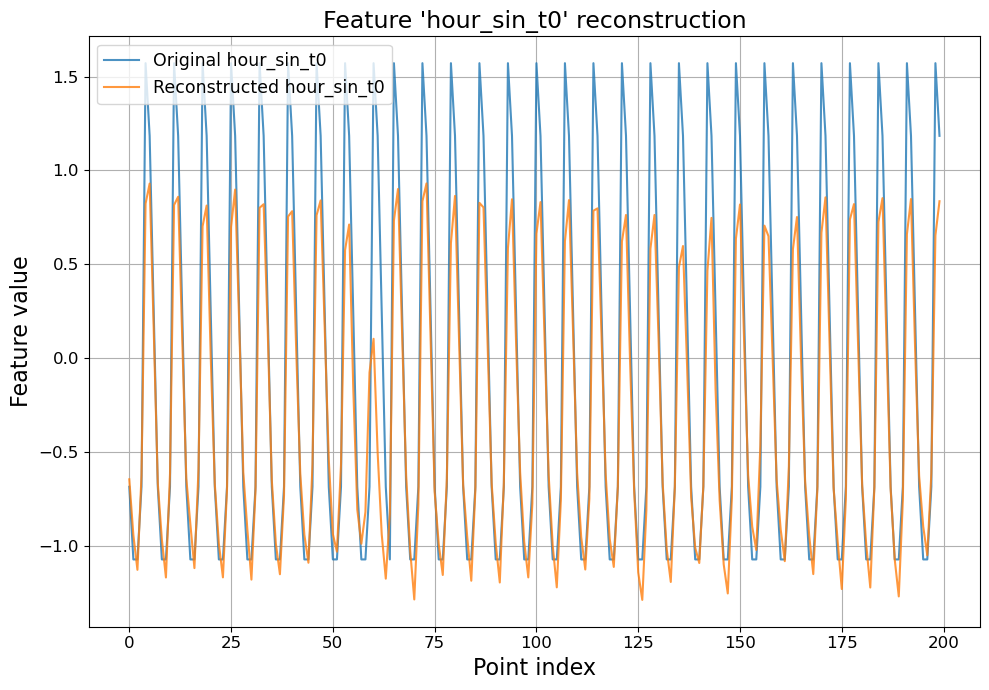

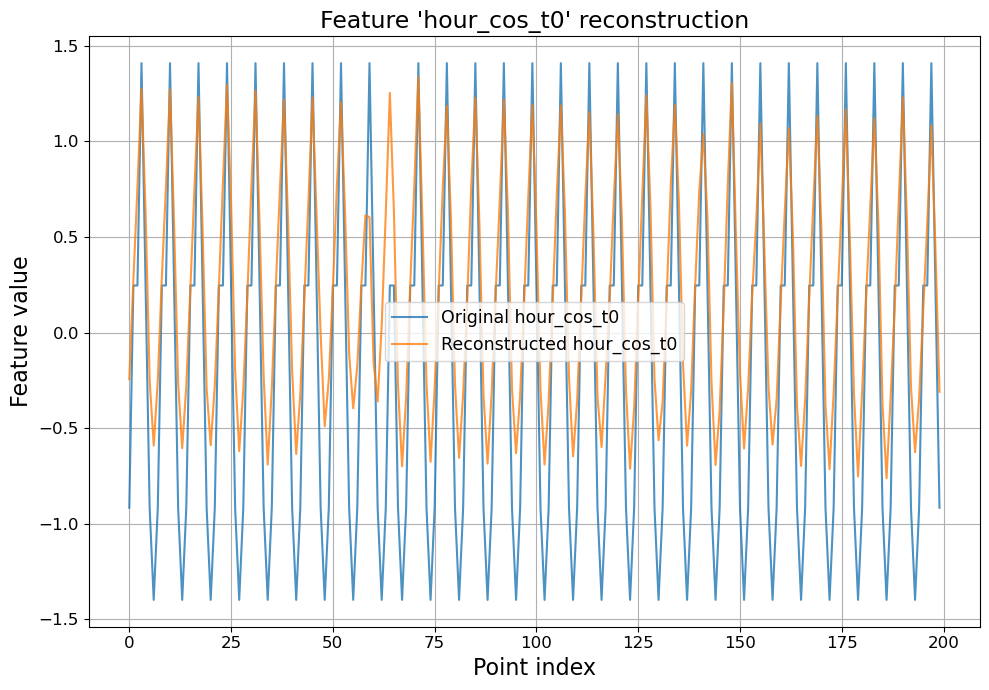

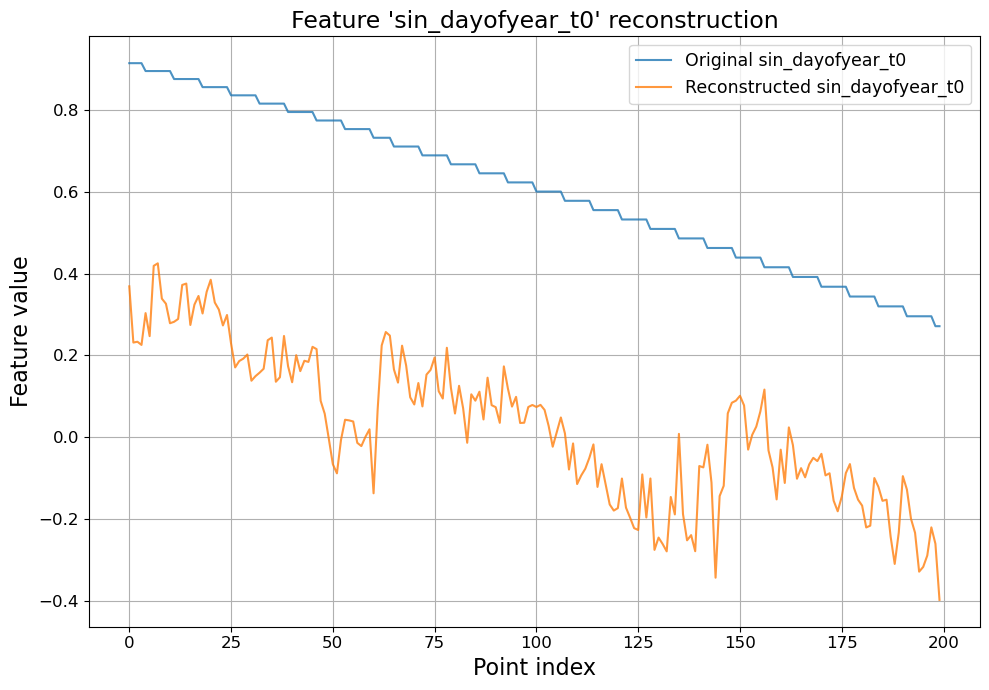

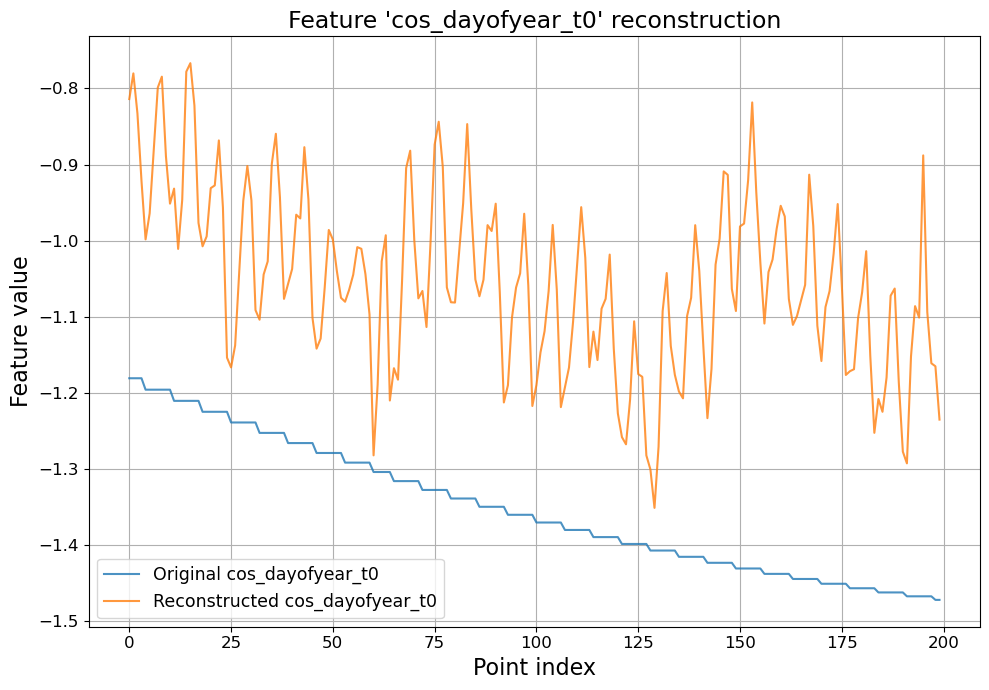

In [126]:
original_all = X_test
reconstructed_all = mean_recon_x_test

# Feature names from dataframe (excluding 'timestamp')
feature_names = df_features.drop(columns=['timestamp']).columns.tolist()

# Select features by index
features_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# How many time steps to plot
points_to_plot = 200
dummy_x = np.arange(points_to_plot)

for feature_idx in features_to_plot:
    plt.figure(figsize=(10, 7))

    plt.plot(dummy_x,
             original_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Original {feature_names[feature_idx]}')

    plt.plot(dummy_x,
             reconstructed_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Reconstructed {feature_names[feature_idx]}')

    plt.xlabel("Point index")
    plt.ylabel("Feature value")
    plt.title(f"Feature '{feature_names[feature_idx]}' reconstruction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    filename = f'plots/VAE_Reconstruction/best_model_3_June_feature_{feature_idx}_beta_1_75_z_16_solar_wind_2VAElayers.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

## Search for best $\beta$ parameter

In [18]:
def objective(trial):

    def get_activation(name):
        return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()}[name]

    beta = trial.suggest_float("beta",50,250, step=25)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 120
    batch_size = 16
    num_folds = 2
    early_stop_patience = 35
    tscv = TimeSeriesSplit(n_splits= num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    best_val_loss = float('inf')
    best_model_state = None

    fold_val_regr_curves = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)
        lambda_tik = 5.04506263165086e-05
        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=256,
            hidden_dim2=128,
            latent_dim=16,
            hidden_dim3=256,
            vae_activation=get_activation('relu'),
            N1=64,
            N2=256,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=lambda_tik
        ).to(device)

        lr = 7.718651039106131e-05
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience= 20)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        no_improve_counter = 0
        best_fold_loss = float('inf')
        fold_val_regr_curve = []

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - 1. / beta) * regr_loss + 1. / beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - 1. / beta) * regr_loss + 1. / beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            epoch_train_losses[epoch] += (train_loss_epoch) / num_folds
            epoch_val_losses[epoch] += (val_loss_epoch) / num_folds
            epoch_val_vae_losses[epoch] += (val_vae_loss_epoch) / num_folds
            epoch_val_regr_losses[epoch] += (val_regr_loss_epoch) / num_folds

            fold_val_regr_curve.append(val_regr_loss_epoch)

            print(f"Epoch [{epoch + 1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_loss_epoch < best_fold_loss: # early stopping
                best_fold_loss = val_loss_epoch
                no_improve_counter = 0
            else:
                no_improve_counter += 1
                if no_improve_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch + 1} in fold {fold + 1}")
                    break

            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                best_model_state = model.state_dict()

        fold_val_regr_curves.append(fold_val_regr_curve)

    model_path = f"weights_VAE_Regression/New_3/model_trial_{trial.number}.pt"
    torch.save(best_model_state, model_path)
    trial.set_user_attr("model_path", model_path)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    trial.set_user_attr("final_vae_loss", epoch_val_vae_losses[-1])
    trial.set_user_attr("final_regr_loss", epoch_val_regr_losses[-1])

    mean_last10_regr_losses = []
    for curve in fold_val_regr_curves:
        if len(curve) >= 10:
            mean_last10_regr_losses.append(np.mean(curve[-10:]))
        else:
            mean_last10_regr_losses.append(np.mean(curve))

    return float(np.mean(mean_last10_regr_losses))


In [21]:
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=50))
from tqdm import tqdm
n_trials = 34
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-06-02 22:14:16,784] A new study created in memory with name: no-name-327af196-e5c1-4f3b-9eaa-2635561b549c
Optuna Trials:   0%|                                                                          | 0/34 [00:00<?, ?trial/s]

Epoch [1/120] - Total val loss: 51.3134, VAE: 692.5533, Regr: 44.8363
Epoch [2/120] - Total val loss: 40.3527, VAE: 724.1716, Regr: 33.4454
Epoch [3/120] - Total val loss: 32.4937, VAE: 736.6615, Regr: 25.3809
Epoch [4/120] - Total val loss: 26.4609, VAE: 734.5551, Regr: 19.3084
Epoch [5/120] - Total val loss: 22.1644, VAE: 730.5513, Regr: 15.0089
Epoch [6/120] - Total val loss: 18.9191, VAE: 707.3046, Regr: 11.9657
Epoch [7/120] - Total val loss: 16.3832, VAE: 643.3808, Regr: 10.0499
Epoch [8/120] - Total val loss: 13.6298, VAE: 568.8786, Regr: 8.0212
Epoch [9/120] - Total val loss: 11.7848, VAE: 524.4077, Regr: 6.6068
Epoch [10/120] - Total val loss: 10.4426, VAE: 492.6290, Regr: 5.5720
Epoch [11/120] - Total val loss: 9.4812, VAE: 466.1676, Regr: 4.8683
Epoch [12/120] - Total val loss: 8.8219, VAE: 447.6980, Regr: 4.3889
Epoch [13/120] - Total val loss: 8.2880, VAE: 436.2217, Regr: 3.9655
Epoch [14/120] - Total val loss: 7.8519, VAE: 425.0735, Regr: 3.6375
Epoch [15/120] - Total val

[I 2025-06-02 22:17:53,238] Trial 0 finished with value: 1.0439959532413765 and parameters: {'beta': 100.0}. Best is trial 0 with value: 1.0439959532413765.
Optuna Trials:   3%|█▊                                                             | 1/34 [03:36<1:59:02, 216.45s/trial]

Epoch [107/120] - Total val loss: 6.3895, VAE: 531.9631, Regr: 1.0807
Early stopping at epoch 107 in fold 2
Epoch [1/120] - Total val loss: 49.9744, VAE: 677.1784, Regr: 44.9163
Epoch [2/120] - Total val loss: 39.9044, VAE: 706.1679, Regr: 34.5313
Epoch [3/120] - Total val loss: 31.8891, VAE: 729.1196, Regr: 26.2663
Epoch [4/120] - Total val loss: 25.9130, VAE: 737.6595, Regr: 20.1731
Epoch [5/120] - Total val loss: 21.3690, VAE: 736.2509, Regr: 15.6038
Epoch [6/120] - Total val loss: 17.8977, VAE: 724.5311, Regr: 12.1991
Epoch [7/120] - Total val loss: 15.0016, VAE: 673.4534, Regr: 9.6915
Epoch [8/120] - Total val loss: 12.6114, VAE: 602.8668, Regr: 7.8513
Epoch [9/120] - Total val loss: 10.7207, VAE: 539.5811, Regr: 6.4557
Epoch [10/120] - Total val loss: 9.3925, VAE: 503.7383, Regr: 5.4058
Epoch [11/120] - Total val loss: 8.4347, VAE: 478.6857, Regr: 4.6423
Epoch [12/120] - Total val loss: 7.6634, VAE: 457.9487, Regr: 4.0320
Epoch [13/120] - Total val loss: 7.3312, VAE: 441.7829, Re

[I 2025-06-02 22:21:23,346] Trial 1 finished with value: 8.870119009993756 and parameters: {'beta': 125.0}. Best is trial 0 with value: 1.0439959532413765.
Optuna Trials:   6%|███▋                                                           | 2/34 [07:06<1:53:27, 212.72s/trial]

...

Epoch [120/120] - Total val loss: 10.9791, VAE: 510.3913, Regr: 0.7870
Epoch [1/120] - Total val loss: 57.4240, VAE: 689.8820, Regr: 44.5167
Epoch [2/120] - Total val loss: 47.0749, VAE: 721.4041, Regr: 33.3131
Epoch [3/120] - Total val loss: 39.4786, VAE: 731.4791, Regr: 25.3561
Epoch [4/120] - Total val loss: 33.4422, VAE: 719.1589, Regr: 19.4480
Epoch [5/120] - Total val loss: 28.1074, VAE: 661.6394, Regr: 15.1781
Epoch [6/120] - Total val loss: 23.5736, VAE: 586.7394, Regr: 12.0804
Epoch [7/120] - Total val loss: 19.9913, VAE: 524.4701, Regr: 9.6958
Epoch [8/120] - Total val loss: 17.6509, VAE: 492.5118, Regr: 7.9599
Epoch [9/120] - Total val loss: 15.7504, VAE: 464.5303, Regr: 6.5916
Epoch [10/120] - Total val loss: 14.3233, VAE: 441.9423, Regr: 5.5964
Epoch [11/120] - Total val loss: 13.3402, VAE: 427.6221, Regr: 4.8855
Epoch [12/120] - Total val loss: 12.4018, VAE: 410.5042, Regr: 4.2773
Epoch [13/120] - Total val loss: 11.6311, VAE: 392.7939, Regr: 3.8523
Epoch [14/120] - Total

[I 2025-06-03 00:06:24,154] Trial 32 finished with value: 0.9224644763488993 and parameters: {'beta': 50.0}. Best is trial 21 with value: 0.6618720856609104.
Optuna Trials:  97%|████████████████████████████████████████████████████████████▏ | 33/34 [1:52:07<03:31, 211.12s/trial]

Epoch [120/120] - Total val loss: 11.6098, VAE: 538.1963, Regr: 0.8631
Epoch [1/120] - Total val loss: 57.9292, VAE: 678.9157, Regr: 45.2560
Epoch [2/120] - Total val loss: 48.0060, VAE: 711.9202, Regr: 34.4568
Epoch [3/120] - Total val loss: 40.3701, VAE: 726.0330, Regr: 26.3770
Epoch [4/120] - Total val loss: 34.9145, VAE: 717.7789, Regr: 20.9785
Epoch [5/120] - Total val loss: 30.4710, VAE: 674.0190, Regr: 17.3374
Epoch [6/120] - Total val loss: 27.3001, VAE: 605.1538, Regr: 15.5072
Epoch [7/120] - Total val loss: 21.3791, VAE: 533.4658, Regr: 10.9284
Epoch [8/120] - Total val loss: 18.8169, VAE: 501.3892, Regr: 8.9685
Epoch [9/120] - Total val loss: 16.6525, VAE: 470.8288, Regr: 7.3836
Epoch [10/120] - Total val loss: 14.8509, VAE: 444.3962, Regr: 6.0847
Epoch [11/120] - Total val loss: 13.4529, VAE: 417.6688, Regr: 5.2036
Epoch [12/120] - Total val loss: 12.4828, VAE: 402.5037, Regr: 4.5231
Epoch [13/120] - Total val loss: 11.3931, VAE: 379.2931, Regr: 3.8849
Epoch [14/120] - Tota

[I 2025-06-03 00:10:15,588] Trial 33 finished with value: 1.090592321096886 and parameters: {'beta': 50.0}. Best is trial 21 with value: 0.6618720856609104.
Optuna Trials: 100%|██████████████████████████████████████████████████████████████| 34/34 [1:55:58<00:00, 204.67s/trial]

Epoch [117/120] - Total val loss: 11.7922, VAE: 534.4852, Regr: 1.1250
Early stopping at epoch 117 in fold 2


## Finer grid search on learning rate and Tikhonov regularization

In [27]:
def objective(trial):

    def get_activation(name):
        return {
            "relu": nn.ReLU(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }[name]

    lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6, 1e-4, log=True)
    lr = trial.suggest_float("lr", 1e-5, 1e-4, log=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 120
    batch_size = 16
    beta = 1./75. ##modify beta based on the best one (as 1/beta)
    num_folds = 3
    patience = 35 # early stopping patience
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    fold_last10_regr_losses = []
    fold_model_paths = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=256,
            hidden_dim2=128,
            latent_dim=16,
            hidden_dim3=256,
            vae_activation=get_activation('relu'),
            N1=64,
            N2=256,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=lambda_tik
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=10
        )

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        val_regr_loss_per_epoch = []
        best_val_regr = float('inf')
        early_stop_counter = 0
        best_model_state = None

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - beta) * regr_loss + beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - beta) * regr_loss + beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            val_regr_loss_per_epoch.append(val_regr_loss_epoch)

            epoch_train_losses[epoch] += train_loss_epoch / num_folds
            epoch_val_losses[epoch] += val_loss_epoch / num_folds
            epoch_val_vae_losses[epoch] += val_vae_loss_epoch / num_folds
            epoch_val_regr_losses[epoch] += val_regr_loss_epoch / num_folds

            print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_regr_loss_epoch < best_val_regr: # early stopping: stop if val regr loss does not imporve for 20 epoxhs
                best_val_regr = val_regr_loss_epoch
                early_stop_counter = 0
                best_model_state = model.state_dict()
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} for fold {fold+1}")
                break

        # save best model state for this fold
        fold_model_path = f"weights_VAE_Regression/New_3/model_trial_{trial.number}_fold_{fold}.pt"
        torch.save(best_model_state, fold_model_path)
        fold_model_paths.append(fold_model_path)

        # average last 10 epochs val regression loss for fold
        fold_avg_regr_last10 = np.mean(val_regr_loss_per_epoch[-10:])
        fold_last10_regr_losses.append(fold_avg_regr_last10)

    # save paths of all fold models in trial attributes
    
    trial.set_user_attr("fold_model_paths", fold_model_paths)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    # return average regression loss across folds (last 10 epochs)
    return np.mean(fold_last10_regr_losses)


In [28]:
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=50))
from tqdm import tqdm
n_trials = 25
for _ in tqdm(range(n_trials), des c="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-06-03 00:23:19,815] A new study created in memory with name: no-name-7b5a39ab-6ef0-42c7-8ce9-dfc796c1aa76
Optuna Trials:   0%|                                                                          | 0/25 [00:00<?, ?trial/s]

Fold 1 Epoch [1/120] - Total val loss: 34.0366, VAE: 471.4561, Regr: 28.1255
Fold 1 Epoch [2/120] - Total val loss: 30.5928, VAE: 478.5414, Regr: 24.5395
Fold 1 Epoch [3/120] - Total val loss: 27.9178, VAE: 489.3827, Regr: 21.6818
Fold 1 Epoch [4/120] - Total val loss: 25.9013, VAE: 499.3755, Regr: 19.5030
Fold 1 Epoch [5/120] - Total val loss: 24.2867, VAE: 504.3299, Regr: 17.7997
Fold 1 Epoch [6/120] - Total val loss: 23.2350, VAE: 509.5025, Regr: 16.6638
Fold 1 Epoch [7/120] - Total val loss: 21.5449, VAE: 513.4743, Regr: 14.8972
Fold 1 Epoch [8/120] - Total val loss: 20.2613, VAE: 514.5429, Regr: 13.5818
Fold 1 Epoch [9/120] - Total val loss: 19.8717, VAE: 514.2489, Regr: 13.1909
Fold 1 Epoch [10/120] - Total val loss: 19.4905, VAE: 512.8434, Regr: 12.8236
Fold 1 Epoch [11/120] - Total val loss: 18.8195, VAE: 512.3846, Regr: 12.1498
Fold 1 Epoch [12/120] - Total val loss: 18.9326, VAE: 509.6448, Regr: 12.3013
Fold 1 Epoch [13/120] - Total val loss: 17.1143, VAE: 503.3211, Regr: 10.

[I 2025-06-03 00:28:52,081] Trial 0 finished with value: 2.019263830757103 and parameters: {'lambda_tik': 3.860771370800708e-05, 'lr': 4.070071491107449e-05}. Best is trial 0 with value: 2.019263830757103.
Optuna Trials:   4%|██▌                                                            | 1/25 [05:32<2:12:54, 332.26s/trial]

Fold 3 Epoch [115/120] - Total val loss: 9.2088, VAE: 535.1348, Regr: 2.1017
Early stopping at epoch 115 for fold 3
Fold 1 Epoch [1/120] - Total val loss: 24.1398, VAE: 465.5327, Regr: 18.1750
Fold 1 Epoch [2/120] - Total val loss: 23.2726, VAE: 465.5377, Regr: 17.2961
Fold 1 Epoch [3/120] - Total val loss: 22.5208, VAE: 467.6940, Regr: 16.5049
Fold 1 Epoch [4/120] - Total val loss: 21.8442, VAE: 473.9103, Regr: 15.7352
Fold 1 Epoch [5/120] - Total val loss: 21.1921, VAE: 478.1956, Regr: 15.0163
Fold 1 Epoch [6/120] - Total val loss: 20.5980, VAE: 483.6878, Regr: 14.3400
Fold 1 Epoch [7/120] - Total val loss: 20.0028, VAE: 486.5269, Regr: 13.6984
Fold 1 Epoch [8/120] - Total val loss: 19.4656, VAE: 491.5897, Regr: 13.0855
Fold 1 Epoch [9/120] - Total val loss: 18.9292, VAE: 495.0386, Regr: 12.4953
Fold 1 Epoch [10/120] - Total val loss: 18.4158, VAE: 497.1611, Regr: 11.9462
Fold 1 Epoch [11/120] - Total val loss: 17.9468, VAE: 500.5409, Regr: 11.4253
Fold 1 Epoch [12/120] - Total val l

[I 2025-06-03 00:34:37,984] Trial 1 finished with value: 2.58731900191842 and parameters: {'lambda_tik': 2.4151385362557125e-05, 'lr': 1.936220778650274e-05}. Best is trial 0 with value: 2.019263830757103.
Optuna Trials:   8%|█████                                                          | 2/25 [11:18<2:10:26, 340.29s/trial]

...

Fold 3 Epoch [120/120] - Total val loss: 8.4345, VAE: 552.1986, Regr: 1.0863
Fold 1 Epoch [1/120] - Total val loss: 15.4921, VAE: 486.2204, Regr: 9.1310
Fold 1 Epoch [2/120] - Total val loss: 13.9791, VAE: 503.4385, Regr: 7.3647
Fold 1 Epoch [3/120] - Total val loss: 12.7653, VAE: 511.5560, Regr: 6.0249
Fold 1 Epoch [4/120] - Total val loss: 11.7230, VAE: 508.2425, Regr: 5.0133
Fold 1 Epoch [5/120] - Total val loss: 10.7765, VAE: 494.2723, Regr: 4.2427
Fold 1 Epoch [6/120] - Total val loss: 9.7256, VAE: 459.3379, Regr: 3.6497
Fold 1 Epoch [7/120] - Total val loss: 8.7527, VAE: 421.2278, Regr: 3.1787
Fold 1 Epoch [8/120] - Total val loss: 7.9138, VAE: 384.6802, Regr: 2.8224
Fold 1 Epoch [9/120] - Total val loss: 7.4025, VAE: 369.2990, Regr: 2.5120
Fold 1 Epoch [10/120] - Total val loss: 6.9422, VAE: 355.0419, Regr: 2.2381
Fold 1 Epoch [11/120] - Total val loss: 6.5899, VAE: 339.6416, Regr: 2.0892
Fold 1 Epoch [12/120] - Total val loss: 6.2278, VAE: 325.1634, Regr: 1.9178
Fold 1 Epoch [1

[I 2025-06-03 02:54:38,624] Trial 23 finished with value: 1.091360884787849 and parameters: {'lambda_tik': 1.3714969011748071e-05, 'lr': 9.976468865228586e-05}. Best is trial 2 with value: 0.7021249399186136.
Optuna Trials:  96%|███████████████████████████████████████████████████████████▌  | 24/25 [2:31:18<04:53, 293.61s/trial]

Fold 3 Epoch [66/120] - Total val loss: 10.8799, VAE: 714.7207, Regr: 1.3685
Early stopping at epoch 66 for fold 3
Fold 1 Epoch [1/120] - Total val loss: 12.5867, VAE: 473.2214, Regr: 6.3619
Fold 1 Epoch [2/120] - Total val loss: 12.1399, VAE: 477.6946, Regr: 5.8486
Fold 1 Epoch [3/120] - Total val loss: 11.8099, VAE: 486.4466, Regr: 5.3959
Fold 1 Epoch [4/120] - Total val loss: 11.5006, VAE: 495.0111, Regr: 4.9667
Fold 1 Epoch [5/120] - Total val loss: 11.2371, VAE: 501.5026, Regr: 4.6118
Fold 1 Epoch [6/120] - Total val loss: 10.9371, VAE: 504.4236, Regr: 4.2684
Fold 1 Epoch [7/120] - Total val loss: 10.6085, VAE: 502.3855, Regr: 3.9629
Fold 1 Epoch [8/120] - Total val loss: 10.3671, VAE: 504.1524, Regr: 3.6943
Fold 1 Epoch [9/120] - Total val loss: 10.1119, VAE: 503.6657, Regr: 3.4423
Fold 1 Epoch [10/120] - Total val loss: 9.8164, VAE: 498.9130, Regr: 3.2070
Fold 1 Epoch [11/120] - Total val loss: 9.4698, VAE: 487.8735, Regr: 3.0049
Fold 1 Epoch [12/120] - Total val loss: 9.1249, V

[I 2025-06-03 03:00:05,331] Trial 24 finished with value: 1.1451567061364842 and parameters: {'lambda_tik': 8.702854795081328e-06, 'lr': 5.341662547268936e-05}. Best is trial 2 with value: 0.7021249399186136.
Optuna Trials: 100%|██████████████████████████████████████████████████████████████| 25/25 [2:36:45<00:00, 376.22s/trial]

Fold 3 Epoch [120/120] - Total val loss: 8.1142, VAE: 526.9771, Regr: 1.1026


In [30]:
print("Full best trial:")
print(study.best_trial)


Full best trial:
FrozenTrial(number=2, state=TrialState.COMPLETE, values=[0.7021249399186136], datetime_start=datetime.datetime(2025, 6, 3, 0, 34, 37, 986787), datetime_complete=datetime.datetime(2025, 6, 3, 0, 57, 7, 549916), params={'lambda_tik': 3.036728864553219e-05, 'lr': 9.755952789852984e-05}, user_attrs={'fold_model_paths': ['weights_VAE_Regression/New_3/model_trial_2_fold_0.pt', 'weights_VAE_Regression/New_3/model_trial_2_fold_1.pt', 'weights_VAE_Regression/New_3/model_trial_2_fold_2.pt'], 'mean_train_loss_curve': [75.13597475565398, 53.83389080283988, 41.59841522498009, 33.121950135271774, 27.029273131973724, 22.542996547670445, 19.144122159888603, 16.805237180147415, 15.07094769854831, 13.773930328524012, 12.804945030273535, 11.989640887731161, 11.304901734376564, 10.717837540002972, 10.26372405861178, 9.875864813470432, 9.550021195768291, 9.238785059278847, 8.952889655645077, 8.726085241533752, 8.466986837550106, 8.267308481228657, 8.071018303816135, 7.892377608861679, 7.74

In [61]:
def objective(trial):
    def get_activation(name):
        return {
            "relu": nn.ReLU(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }[name]

    #lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6, 1e-4, log=True)
    lr = trial.suggest_categorical("lr", [9.755952789852984e-05])
    lambda_tik=3.036728864553219e-05
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 200
    batch_size = 16
    beta = 1./1000.
    patience = 35  # early stopping patience

    val_split_ratio = 0.5
    split_idx = int((1 - val_split_ratio) * len(X_train_tensor))
    X_train_fold = X_train_tensor[:split_idx]
    Y_train_fold = Y_train_tensor[:split_idx]
    X_val_fold = X_train_tensor[split_idx:]
    Y_val_fold = Y_train_tensor[split_idx:]

    train_dataset = TensorDataset(X_train_fold, Y_train_fold)
    val_dataset = TensorDataset(X_val_fold, Y_val_fold)

    model = VAE_Regression(
        input_dim=X_train_fold.shape[1],
        hidden_dim1=256,
        hidden_dim2=128,
        latent_dim=16,
        hidden_dim3=256,
        vae_activation=get_activation('relu'),
        N1=64,
        N2=256,
        No=Y_train_fold.shape[1],
        activation=get_activation('relu'),
        lambda_tik=lambda_tik
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=20
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    val_regr_loss_per_epoch = []
    best_val_regr = float('inf')
    early_stop_counter = 0
    best_model_state = None

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    for epoch in range(num_epochs):
        model.train()
        train_loss_epoch = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()

            regr_output, recon_x, mu, logvar, _ = model(x_batch)
            vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
            regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

            loss = (1 - beta) * regr_loss + beta * vae_loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_epoch += loss.item()

        train_loss_epoch /= len(train_loader)
        scheduler.step(train_loss_epoch)

        model.eval()
        val_loss_epoch = 0.
        val_vae_loss_epoch = 0.
        val_regr_loss_epoch = 0.

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                val_loss = (1 - beta) * regr_loss + beta * vae_loss

                val_loss_epoch += val_loss.item()
                val_vae_loss_epoch += vae_loss.item()
                val_regr_loss_epoch += regr_loss.item()

        val_loss_epoch /= len(val_loader)
        val_vae_loss_epoch /= len(val_loader)
        val_regr_loss_epoch /= len(val_loader)

        val_regr_loss_per_epoch.append(val_regr_loss_epoch)

        epoch_train_losses[epoch] = train_loss_epoch
        epoch_val_losses[epoch] = val_loss_epoch
        epoch_val_vae_losses[epoch] = val_vae_loss_epoch
        epoch_val_regr_losses[epoch] = val_regr_loss_epoch

        print(f"Epoch [{epoch+1}/{num_epochs}] - Val loss: {val_loss_epoch:.4f}, VAE: {val_vae_loss_epoch:.4f}, Regr: {val_regr_loss_epoch:.4f}")

        if val_regr_loss_epoch < best_val_regr:
            best_val_regr = val_regr_loss_epoch
            early_stop_counter = 0
            best_model_state = model.state_dict()
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model_path = f"weights_VAE_Regression/New_3/model_trial_{trial.number}.pt"
    torch.save(best_model_state, model_path)

    trial.set_user_attr("model_path", model_path)
    trial.set_user_attr("train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("val_regr_loss_curve", epoch_val_regr_losses.tolist())

    return np.mean(val_regr_loss_per_epoch[-10:])


In [62]:
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=50))
from tqdm.notebook import tqdm
n_trials = 10
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-06-03 11:36:51,911] A new study created in memory with name: no-name-f10b28dc-6564-491d-b8cb-a637c8a5cb31


Optuna Trials:   0%|          | 0/10 [00:00<?, ?trial/s]

Epoch [1/200] - Val loss: 45.0977, VAE: 1630.2476, Regr: 43.5110
Epoch [2/200] - Val loss: 28.8580, VAE: 1675.9229, Regr: 27.2093
Epoch [3/200] - Val loss: 19.5528, VAE: 1694.7862, Regr: 17.8759
Epoch [4/200] - Val loss: 14.1670, VAE: 1695.4547, Regr: 12.4841
Epoch [5/200] - Val loss: 11.0957, VAE: 1682.9043, Regr: 9.4222
Epoch [6/200] - Val loss: 9.1978, VAE: 1677.8917, Regr: 7.5274
Epoch [7/200] - Val loss: 8.0985, VAE: 1651.2876, Regr: 6.4537
Epoch [8/200] - Val loss: 7.4984, VAE: 1616.1302, Regr: 5.8882
Epoch [9/200] - Val loss: 7.0179, VAE: 1535.1320, Regr: 5.4883
Epoch [10/200] - Val loss: 6.6335, VAE: 1461.0440, Regr: 5.1776
Epoch [11/200] - Val loss: 6.2709, VAE: 1411.6628, Regr: 4.8641
Epoch [12/200] - Val loss: 6.0182, VAE: 1380.8334, Regr: 4.6420
Epoch [13/200] - Val loss: 5.7862, VAE: 1347.0865, Regr: 4.4435
Epoch [14/200] - Val loss: 5.5262, VAE: 1309.7748, Regr: 4.2207
Epoch [15/200] - Val loss: 5.2940, VAE: 1257.4698, Regr: 4.0405
Epoch [16/200] - Val loss: 5.0018, VAE: 

[I 2025-06-03 11:38:36,897] Trial 0 finished with value: 2.547332264461483 and parameters: {'lr': 9.755952789852984e-05}. Best is trial 0 with value: 2.547332264461483.


Epoch [94/200] - Val loss: 3.0095, VAE: 579.0265, Regr: 2.4329
Early stopping at epoch 94
Epoch [1/200] - Val loss: 44.2787, VAE: 1658.6116, Regr: 42.6628
Epoch [2/200] - Val loss: 28.5150, VAE: 1689.4902, Regr: 26.8524
Epoch [3/200] - Val loss: 19.4932, VAE: 1708.0628, Regr: 17.8030
Epoch [4/200] - Val loss: 14.1601, VAE: 1703.0922, Regr: 12.4694
Epoch [5/200] - Val loss: 11.2665, VAE: 1687.4700, Regr: 9.5887
Epoch [6/200] - Val loss: 9.3264, VAE: 1685.5454, Regr: 7.6485
Epoch [7/200] - Val loss: 8.2328, VAE: 1677.1835, Regr: 6.5622
Epoch [8/200] - Val loss: 7.6921, VAE: 1657.0195, Regr: 6.0411
Epoch [9/200] - Val loss: 7.0617, VAE: 1633.5090, Regr: 5.4336
Epoch [10/200] - Val loss: 6.6507, VAE: 1595.6039, Regr: 5.0602
Epoch [11/200] - Val loss: 6.2839, VAE: 1539.7873, Regr: 4.7488
Epoch [12/200] - Val loss: 5.9265, VAE: 1471.9844, Regr: 4.4590
Epoch [13/200] - Val loss: 5.8055, VAE: 1438.2247, Regr: 4.3717
Epoch [14/200] - Val loss: 5.6494, VAE: 1404.6613, Regr: 4.2490
Epoch [15/200]

...

Epoch [137/200] - Val loss: 1.7401, VAE: 548.9370, Regr: 1.1924
Early stopping at epoch 137
Epoch [1/200] - Val loss: 44.9192, VAE: 1617.1816, Regr: 43.3453
Epoch [2/200] - Val loss: 29.9461, VAE: 1684.8720, Regr: 28.2895
Epoch [3/200] - Val loss: 20.8688, VAE: 1716.0807, Regr: 19.1719
Epoch [4/200] - Val loss: 15.3699, VAE: 1709.0330, Regr: 13.6745
Epoch [5/200] - Val loss: 11.9084, VAE: 1698.0813, Regr: 10.2205
Epoch [6/200] - Val loss: 9.6845, VAE: 1683.8270, Regr: 8.0087
Epoch [7/200] - Val loss: 8.2314, VAE: 1658.1242, Regr: 6.5798
Epoch [8/200] - Val loss: 7.6062, VAE: 1635.0374, Regr: 5.9772
Epoch [9/200] - Val loss: 6.9874, VAE: 1573.1012, Regr: 5.4197
Epoch [10/200] - Val loss: 6.6541, VAE: 1515.8657, Regr: 5.1433
Epoch [11/200] - Val loss: 6.3524, VAE: 1467.7339, Regr: 4.8896
Epoch [12/200] - Val loss: 5.9904, VAE: 1421.4858, Regr: 4.5735
Epoch [13/200] - Val loss: 5.7910, VAE: 1384.5920, Regr: 4.4108
Epoch [14/200] - Val loss: 5.5085, VAE: 1328.8191, Regr: 4.1839
Epoch [15/2

KeyboardInterrupt: 

Epoch [98/200] - Val loss: 1.8638, VAE: 625.8386, Regr: 1.2392
Epoch [99/200] - Val loss: 1.8813, VAE: 620.2983, Regr: 1.2622
Epoch [100/200] - Val loss: 1.8615, VAE: 613.5405, Regr: 1.2492
Epoch [101/200] - Val loss: 1.7976, VAE: 617.9827, Regr: 1.1808


[W 2025-06-03 11:43:14,314] Trial 2 failed with parameters: {'lr': 9.755952789852984e-05} because of the following error: ZMQError('Socket operation on non-socket').
Traceback (most recent call last):
  File "/home/samu/miniconda3/envs/myenv/lib/python3.9/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_680/3374678565.py", line 115, in objective
    print(f"Epoch [{epoch+1}/{num_epochs}] - Val loss: {val_loss_epoch:.4f}, VAE: {val_vae_loss_epoch:.4f}, Regr: {val_regr_loss_epoch:.4f}")
  File "/home/samu/miniconda3/envs/myenv/lib/python3.9/site-packages/ipykernel/iostream.py", line 694, in write
    self._schedule_flush()
  File "/home/samu/miniconda3/envs/myenv/lib/python3.9/site-packages/ipykernel/iostream.py", line 590, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/home/samu/miniconda3/envs/myenv/lib/python3.9/site-packages/ipykernel/iostream.py", line 267, in schedule
    self._

Epoch [102/200] - Val loss: 1.8461, VAE: 616.1026, Regr: 1.2313

In [67]:
def objective(trial):

    def get_activation(name):
        return {
            "relu": nn.ReLU(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }[name]

    #lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6, 1e-4, log=True)
    #lr = trial.suggest_float("lr", 1e-5, 1e-4, log=True)
    lr = trial.suggest_categorical("lr", [9.755952789852984e-05])
    lambda_tik=3.036728864553219e-05

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 120
    batch_size = 16
    beta = 1./75. ##modify beta based on the best one (as 1/beta)
    num_folds = 2
    patience = 30 # early stopping patience
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    fold_last10_regr_losses = []
    fold_model_paths = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=256,
            hidden_dim2=128,
            latent_dim=16,
            hidden_dim3=256,
            vae_activation=get_activation('relu'),
            N1=64,
            N2=256,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=lambda_tik
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=20
        )

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        val_regr_loss_per_epoch = []
        best_val_regr = float('inf')
        early_stop_counter = 0
        best_model_state = None

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - beta) * regr_loss + beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - beta) * regr_loss + beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            val_regr_loss_per_epoch.append(val_regr_loss_epoch)

            epoch_train_losses[epoch] += train_loss_epoch / num_folds
            epoch_val_losses[epoch] += val_loss_epoch / num_folds
            epoch_val_vae_losses[epoch] += val_vae_loss_epoch / num_folds
            epoch_val_regr_losses[epoch] += val_regr_loss_epoch / num_folds

            print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_regr_loss_epoch < best_val_regr: # early stopping: stop if val regr loss does not imporve for 20 epoxhs
                best_val_regr = val_regr_loss_epoch
                early_stop_counter = 0
                best_model_state = model.state_dict()
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} for fold {fold+1}")
                break

        # save best model state for this fold
        fold_model_path = f"weights_VAE_Regression/New_3/model_trial_{trial.number}_fold_{fold}.pt"
        torch.save(best_model_state, fold_model_path)
        fold_model_paths.append(fold_model_path)

        # average last 10 epochs val regression loss for fold
        fold_avg_regr_last10 = np.mean(val_regr_loss_per_epoch[-10:])
        fold_last10_regr_losses.append(fold_avg_regr_last10)

    # save paths of all fold models in trial attributes
    
    trial.set_user_attr("fold_model_paths", fold_model_paths)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    # return average regression loss across folds (last 10 epochs)
    return np.mean(fold_last10_regr_losses)


In [68]:
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=50))
from tqdm.notebook import tqdm
n_trials = 10
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-06-03 11:48:04,401] A new study created in memory with name: no-name-62c2bf2f-453f-4d00-b92a-dcc198facebf


Optuna Trials:   0%|          | 0/10 [00:00<?, ?trial/s]

Fold 1 Epoch [1/120] - Total val loss: 34.9413, VAE: 697.9962, Regr: 25.9811
Fold 1 Epoch [2/120] - Total val loss: 28.0508, VAE: 737.3631, Regr: 18.4655
Fold 1 Epoch [3/120] - Total val loss: 23.0808, VAE: 741.7372, Regr: 13.3692
Fold 1 Epoch [4/120] - Total val loss: 19.6195, VAE: 735.6915, Regr: 9.9428
Fold 1 Epoch [5/120] - Total val loss: 16.8248, VAE: 694.1048, Regr: 7.6723
Fold 1 Epoch [6/120] - Total val loss: 14.3365, VAE: 622.3443, Regr: 6.1201
Fold 1 Epoch [7/120] - Total val loss: 12.7983, VAE: 584.8475, Regr: 5.0679
Fold 1 Epoch [8/120] - Total val loss: 11.3104, VAE: 529.8372, Regr: 4.3033
Fold 1 Epoch [9/120] - Total val loss: 10.3191, VAE: 493.6498, Regr: 3.7876
Fold 1 Epoch [10/120] - Total val loss: 9.5894, VAE: 468.9513, Regr: 3.3818
Fold 1 Epoch [11/120] - Total val loss: 8.9282, VAE: 442.9637, Regr: 3.0629
Fold 1 Epoch [12/120] - Total val loss: 8.7573, VAE: 424.5461, Regr: 3.1386
Fold 1 Epoch [13/120] - Total val loss: 8.0872, VAE: 403.9418, Regr: 2.7378
Fold 1 Ep

[I 2025-06-03 11:51:13,921] Trial 0 finished with value: 0.696012646983639 and parameters: {'lr': 9.755952789852984e-05}. Best is trial 0 with value: 0.696012646983639.


Fold 2 Epoch [79/120] - Total val loss: 8.5498, VAE: 580.9171, Regr: 0.8151
Early stopping at epoch 79 for fold 2
Fold 1 Epoch [1/120] - Total val loss: 35.2135, VAE: 694.8713, Regr: 26.2992
Fold 1 Epoch [2/120] - Total val loss: 27.9576, VAE: 737.9059, Regr: 18.3637
Fold 1 Epoch [3/120] - Total val loss: 22.9693, VAE: 738.5169, Regr: 13.2998
Fold 1 Epoch [4/120] - Total val loss: 19.3641, VAE: 723.4332, Regr: 9.8496
Fold 1 Epoch [5/120] - Total val loss: 16.2217, VAE: 657.5936, Regr: 7.5545
Fold 1 Epoch [6/120] - Total val loss: 13.8581, VAE: 591.9544, Regr: 6.0460
Fold 1 Epoch [7/120] - Total val loss: 11.9204, VAE: 524.8288, Regr: 4.9892
Fold 1 Epoch [8/120] - Total val loss: 10.3419, VAE: 462.6785, Regr: 4.2292
Fold 1 Epoch [9/120] - Total val loss: 9.6240, VAE: 451.3391, Regr: 3.6549
Fold 1 Epoch [10/120] - Total val loss: 9.0200, VAE: 442.5849, Regr: 3.1610
Fold 1 Epoch [11/120] - Total val loss: 8.5270, VAE: 425.7205, Regr: 2.8892
Fold 1 Epoch [12/120] - Total val loss: 8.0992, 

...

Fold 2 Epoch [97/120] - Total val loss: 8.5088, VAE: 543.6801, Regr: 1.2767
Early stopping at epoch 97 for fold 2
Fold 1 Epoch [1/120] - Total val loss: 35.8157, VAE: 722.4983, Regr: 26.5362
Fold 1 Epoch [2/120] - Total val loss: 27.9108, VAE: 735.7704, Regr: 18.3452
Fold 1 Epoch [3/120] - Total val loss: 22.7886, VAE: 732.3361, Regr: 13.2002
Fold 1 Epoch [4/120] - Total val loss: 19.1115, VAE: 708.3869, Regr: 9.7970
Fold 1 Epoch [5/120] - Total val loss: 16.2046, VAE: 660.4432, Regr: 7.4987
Fold 1 Epoch [6/120] - Total val loss: 13.8288, VAE: 591.2719, Regr: 6.0255
Fold 1 Epoch [7/120] - Total val loss: 11.8064, VAE: 517.4354, Regr: 4.9736
Fold 1 Epoch [8/120] - Total val loss: 10.4512, VAE: 469.3219, Regr: 4.2502
Fold 1 Epoch [9/120] - Total val loss: 9.6919, VAE: 453.7454, Regr: 3.6912
Fold 1 Epoch [10/120] - Total val loss: 9.2080, VAE: 450.7141, Regr: 3.2417
Fold 1 Epoch [11/120] - Total val loss: 8.7329, VAE: 434.1404, Regr: 2.9842
Fold 1 Epoch [12/120] - Total val loss: 8.1483, 

[I 2025-06-03 12:18:16,857] Trial 8 finished with value: 0.8412562609415688 and parameters: {'lr': 9.755952789852984e-05}. Best is trial 4 with value: 0.6721974942658981.


Fold 2 Epoch [120/120] - Total val loss: 8.3868, VAE: 565.4158, Regr: 0.8593
Fold 1 Epoch [1/120] - Total val loss: 34.9291, VAE: 703.6959, Regr: 25.8917
Fold 1 Epoch [2/120] - Total val loss: 27.3669, VAE: 734.4696, Regr: 17.8115
Fold 1 Epoch [3/120] - Total val loss: 22.4656, VAE: 735.8541, Regr: 12.8252
Fold 1 Epoch [4/120] - Total val loss: 18.7740, VAE: 699.8468, Regr: 9.5704
Fold 1 Epoch [5/120] - Total val loss: 15.7723, VAE: 631.9130, Regr: 7.4461
Fold 1 Epoch [6/120] - Total val loss: 13.8833, VAE: 584.2440, Regr: 6.1758
Fold 1 Epoch [7/120] - Total val loss: 12.0052, VAE: 530.0547, Regr: 5.0046
Fold 1 Epoch [8/120] - Total val loss: 10.4256, VAE: 472.0718, Regr: 4.1871
Fold 1 Epoch [9/120] - Total val loss: 9.5761, VAE: 443.0638, Regr: 3.7182
Fold 1 Epoch [10/120] - Total val loss: 9.0916, VAE: 445.6573, Regr: 3.1920
Fold 1 Epoch [11/120] - Total val loss: 8.6437, VAE: 434.6226, Regr: 2.8872
Fold 1 Epoch [12/120] - Total val loss: 8.1253, VAE: 413.3549, Regr: 2.6492
Fold 1 Ep

[I 2025-06-03 12:21:42,408] Trial 9 finished with value: 1.1787842074342127 and parameters: {'lr': 9.755952789852984e-05}. Best is trial 4 with value: 0.6721974942658981.


Fold 2 Epoch [89/120] - Total val loss: 9.1166, VAE: 562.8702, Regr: 1.6334
Early stopping at epoch 89 for fold 2


In [116]:
import json

# choose the model with best trade-off between regression and valid loss
best_trial= study.best_trial


# get its best hyperparameters
best_activation = get_activation("relu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


best_model = VAE_Regression(
            input_dim=X_train.shape[1],
            hidden_dim1=256,
            hidden_dim2=128,
            latent_dim=16,
            hidden_dim3=256,
            vae_activation=get_activation('relu'),
            N1=64,
            N2=256,
            No=Y_train.shape[1],
            activation=get_activation('relu'),
            lambda_tik=3.036728864553219e-05
        ).to(device)

lr = 9.755952789852984e-05
beta = 1./75. 


# load the weights of the best trial
best_model.load_state_dict(torch.load(best_trial.user_attrs["fold_model_paths"][0]))

trial=0
trial += 1
# saves current hyperparamters and weights (which you just loaded) into a new file

with open("best_Regr_models/best_model_3_June_hyperparams.json", "w") as f:
    json.dump(best_params, f)

torch.save(best_model.state_dict(), f"best_Regr_models/best_model_3_June_{trial}.pt")


In [81]:
best_trial

FrozenTrial(number=4, state=TrialState.COMPLETE, values=[0.6721974942658981], datetime_start=datetime.datetime(2025, 6, 3, 12, 0, 28, 335902), datetime_complete=datetime.datetime(2025, 6, 3, 12, 3, 48, 473951), params={'lr': 9.755952789852984e-05}, user_attrs={'fold_model_paths': ['weights_VAE_Regression/New_3/model_trial_4_fold_0.pt', 'weights_VAE_Regression/New_3/model_trial_4_fold_1.pt'], 'mean_train_loss_curve': [74.97084942824549, 52.37136206180929, 40.05827555553519, 31.465276134957513, 24.86790386035288, 20.82253135279786, 17.645521340610312, 15.35685482299585, 13.842726198889368, 12.743494676171448, 11.94627441605218, 11.33473676314457, 10.784667378706898, 10.252039549162062, 9.755702106643923, 9.364486281391528, 9.004740907133913, 8.723127115115844, 8.486069722998915, 8.246895745503817, 8.020122291372834, 7.814722209525623, 7.631641616924204, 7.454243722579462, 7.2686804022720395, 7.102129653203402, 6.942871729675814, 6.824714392209224, 6.7346305242545315, 6.582993280115745, 6

'weights_VAE_Regression/New_3/model_trial_4_fold_0.pt'